In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))

from utils.common import config

In [2]:
# Sampling site coordinates (Mjøsa origin)
LAT_CENTER = config.LAT0  # 60.801146°N
LON_CENTER = config.LON0  # 10.705125°E

print(f"Sampling site center: {LAT_CENTER}°N, {LON_CENTER}°E")

Sampling site center: 60.801146°N, 10.705125°E


In [3]:
# Map extent (adjust these to zoom in/out)
extent_km = 5  # kilometers around center

# Convert km to degrees (approximate at this latitude)
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.radians(LAT_CENTER))

lat_span = extent_km / km_per_deg_lat
lon_span = extent_km / km_per_deg_lon

extent = [
    LON_CENTER - lon_span,  # left
    LON_CENTER + lon_span,  # right
    LAT_CENTER - lat_span,  # bottom
    LAT_CENTER + lat_span,  # top
]

print(f"Map extent: {extent_km} km around center")
print(f"Longitude: {extent[0]:.4f}°E to {extent[1]:.4f}°E")
print(f"Latitude: {extent[2]:.4f}°N to {extent[3]:.4f}°N")

Map extent: 5 km around center
Longitude: 10.6128°E to 10.7975°E
Latitude: 60.7561°N to 60.8462°N


## Style 1: Natural Earth - Physical Features Only

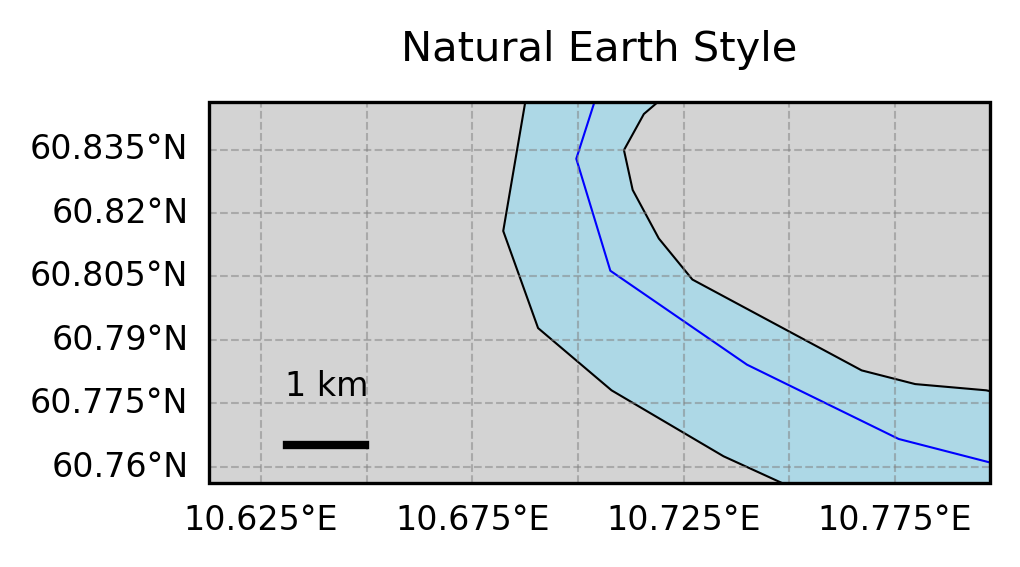

In [4]:
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add land and water features
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAKES, facecolor="lightblue", edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.5)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Add scale bar (approximate)
scale_km = 1  # 1 km scale bar
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.title("Natural Earth Style", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Style 2: High Resolution - Detailed Coastlines

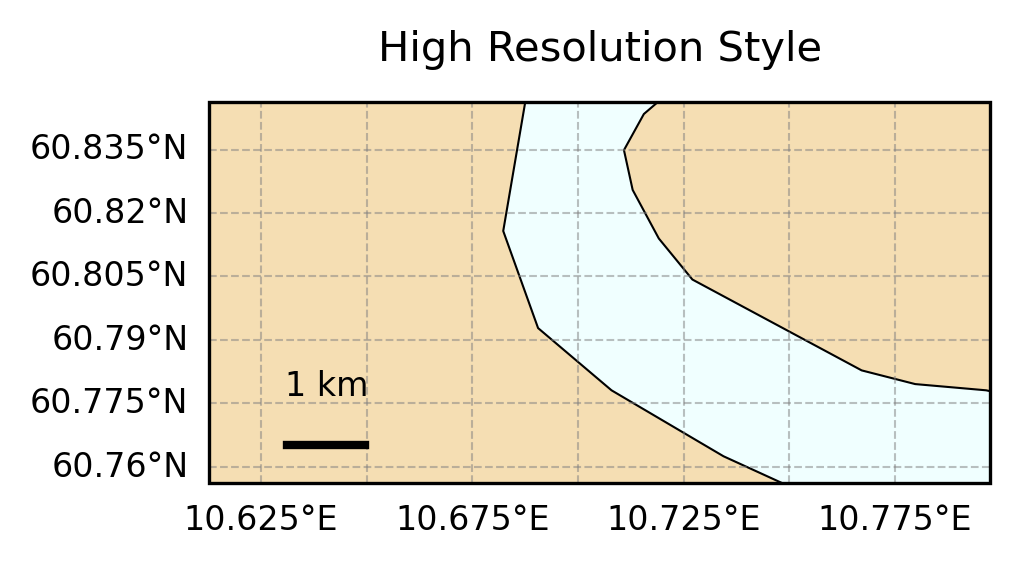

In [5]:
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# High resolution coastlines and borders
ax.coastlines(resolution="10m", linewidth=0.8, color="black")
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="wheat", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="azure")
ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="azure",
    edgecolor="black",
    linewidth=0.5,
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.title("High Resolution Style", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Style 3: Minimalist - Land/Water Only

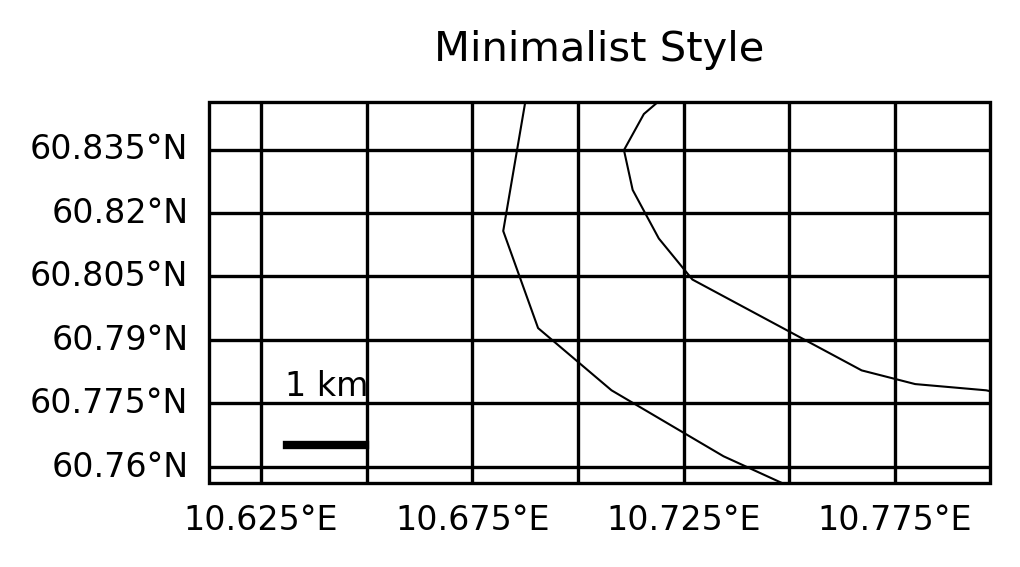

In [6]:
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Minimalist: just land and water
ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.LAKES, facecolor="white", edgecolor="black", linewidth=0.5)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.8, color="black", alpha=1.0, linestyle="-"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.title("Minimalist Style", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Adjust Map Extent
Change `extent_km` value and re-run the cells above to zoom in/out

In [7]:
# Try different zoom levels
for zoom_km in [2, 5, 10, 20]:
    lat_span = zoom_km / km_per_deg_lat
    lon_span = zoom_km / km_per_deg_lon

    test_extent = [
        LON_CENTER - lon_span,
        LON_CENTER + lon_span,
        LAT_CENTER - lat_span,
        LAT_CENTER + lat_span,
    ]

    print(f"\n{zoom_km} km extent:")
    print(f"  Lon: {test_extent[0]:.4f}°E to {test_extent[1]:.4f}°E")
    print(f"  Lat: {test_extent[2]:.4f}°N to {test_extent[3]:.4f}°N")


2 km extent:
  Lon: 10.6682°E to 10.7421°E
  Lat: 60.7831°N to 60.8192°N

5 km extent:
  Lon: 10.6128°E to 10.7975°E
  Lat: 60.7561°N to 60.8462°N

10 km extent:
  Lon: 10.5205°E to 10.8898°E
  Lat: 60.7111°N to 60.8912°N

20 km extent:
  Lon: 10.3358°E to 11.0745°E
  Lat: 60.6210°N to 60.9813°N


## Save Final Version
Once you've chosen your preferred style and extent

Saved: publication_map_natural_earth_5km.png


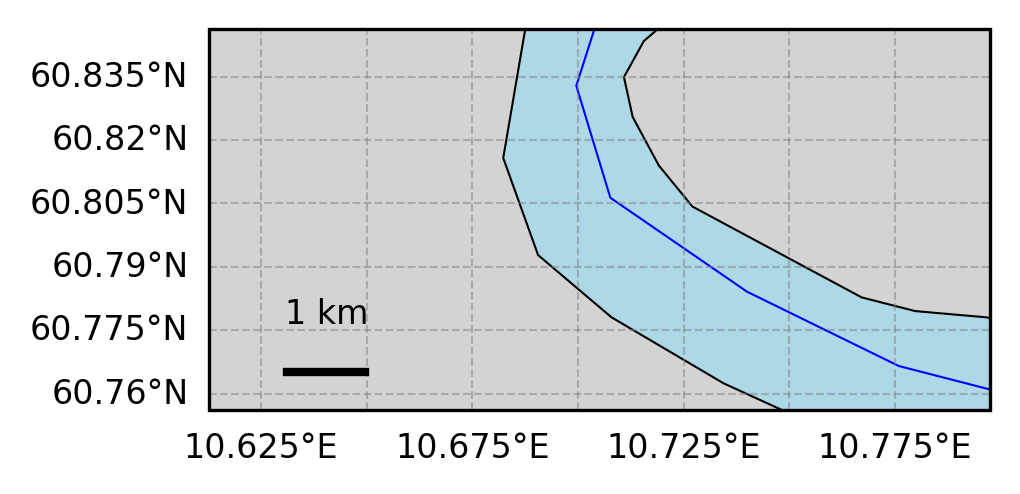

In [8]:
# Set your final parameters
FINAL_EXTENT_KM = 5  # Choose your zoom level
FINAL_STYLE = "natural_earth"  # 'natural_earth', 'high_res', or 'minimalist'
OUTPUT_FORMAT = "png"  # 'png', 'pdf', 'svg', 'tiff'
OUTPUT_DPI = 300

# Calculate extent
lat_span = FINAL_EXTENT_KM / km_per_deg_lat
lon_span = FINAL_EXTENT_KM / km_per_deg_lon
final_extent = [
    LON_CENTER - lon_span,
    LON_CENTER + lon_span,
    LAT_CENTER - lat_span,
    LAT_CENTER + lat_span,
]

# Create figure
fig = plt.figure(figsize=(3.5, 3.5), dpi=OUTPUT_DPI)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(final_extent, crs=ccrs.PlateCarree())

# Apply chosen style
if FINAL_STYLE == "natural_earth":
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(
        cfeature.LAKES, facecolor="lightblue", edgecolor="black", linewidth=0.5
    )
    ax.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.5)
elif FINAL_STYLE == "high_res":
    ax.coastlines(resolution="10m", linewidth=0.8, color="black")
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="wheat", edgecolor="none")
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="azure")
    ax.add_feature(
        cfeature.LAKES.with_scale("10m"),
        facecolor="azure",
        edgecolor="black",
        linewidth=0.5,
    )
elif FINAL_STYLE == "minimalist":
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="black", linewidth=0.8)
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.add_feature(cfeature.LAKES, facecolor="white", edgecolor="black", linewidth=0.5)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = final_extent[0] + 0.1 * (final_extent[1] - final_extent[0])
scale_y = final_extent[2] + 0.1 * (final_extent[3] - final_extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.tight_layout()

# Save
output_file = f"publication_map_{FINAL_STYLE}_{FINAL_EXTENT_KM}km.{OUTPUT_FORMAT}"
plt.savefig(output_file, dpi=OUTPUT_DPI, bbox_inches="tight", facecolor="white")
print(f"Saved: {output_file}")
plt.show()

## High-Resolution Map with Real Basemap Tiles
Uses actual map tiles for detailed background

NameError: name 'extent' is not defined

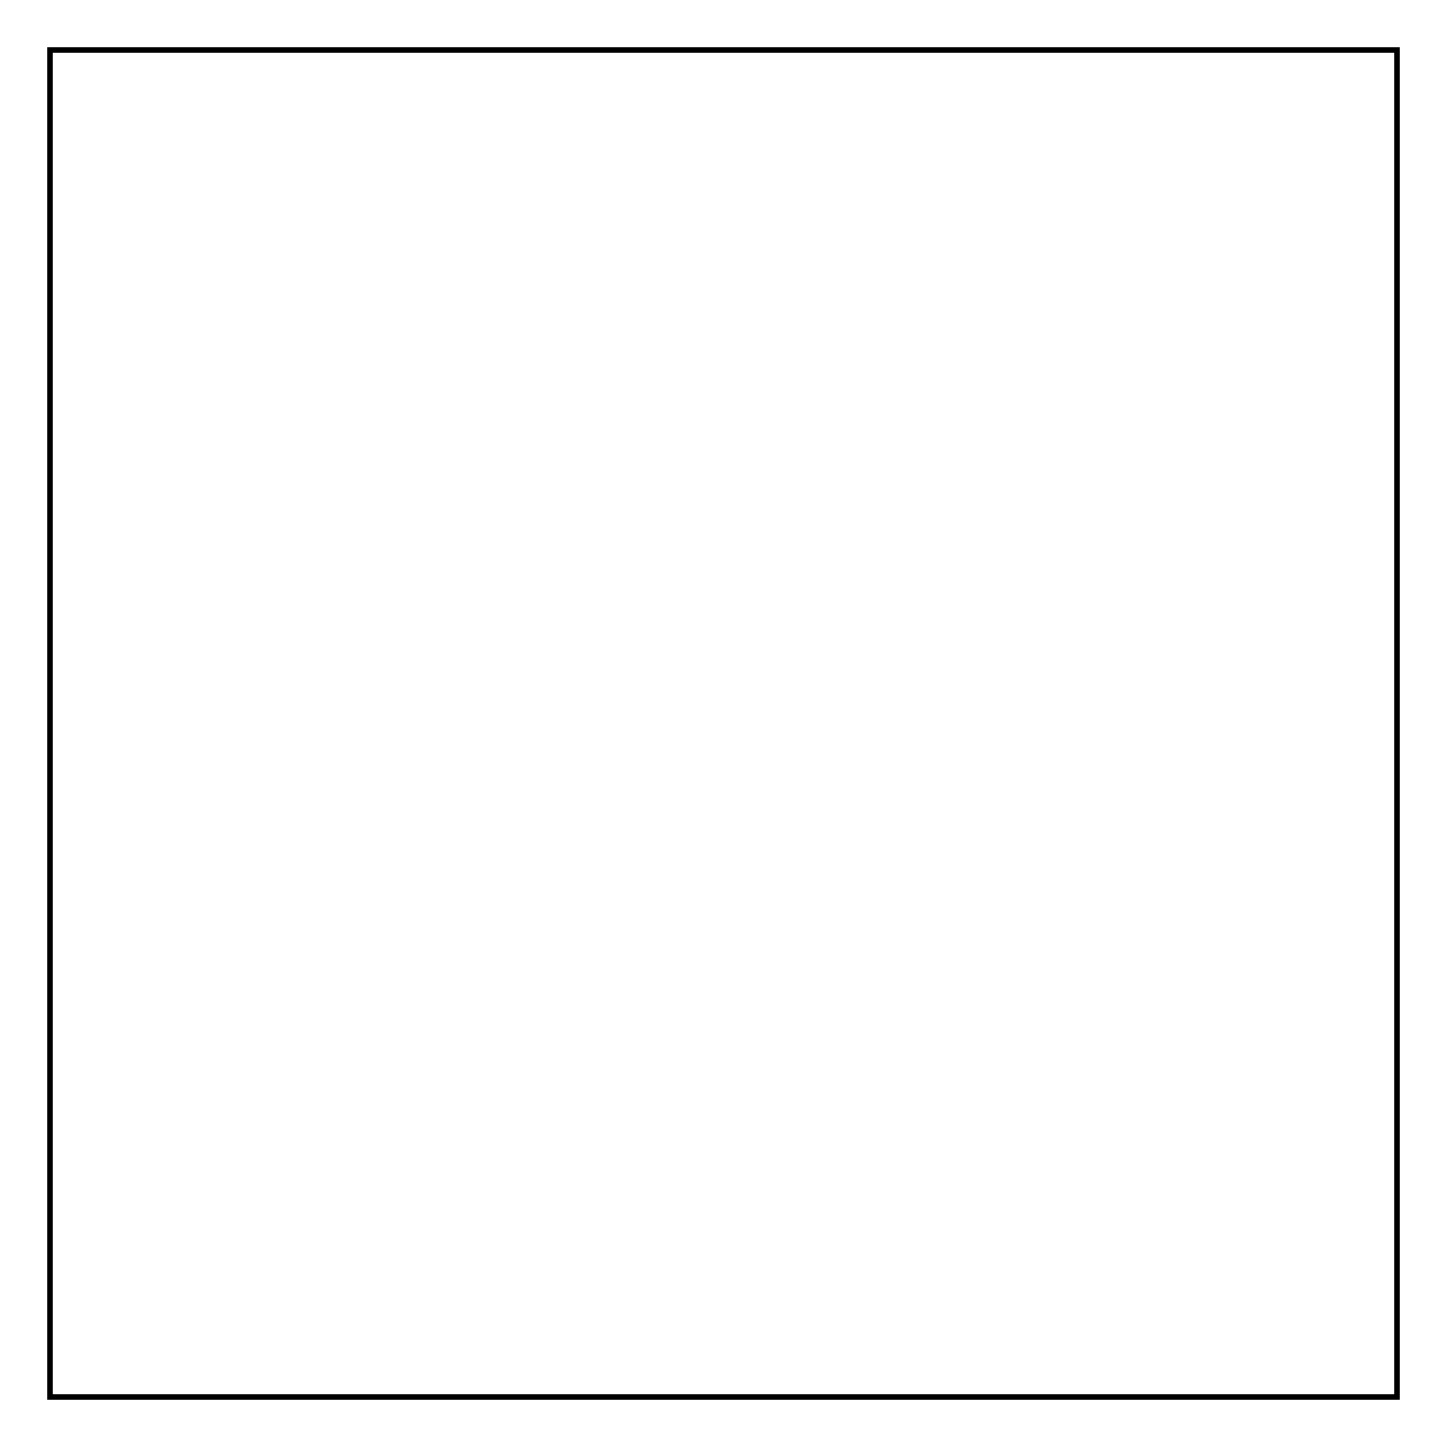

In [ ]:
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt

# Option 1: OpenStreetMap - most detailed
fig = plt.figure(figsize=(3.5, 3.5), dpi=500)
tile_source = cimgt.OSM()
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map tiles at appropriate zoom level (higher = more detail)
# For 2x2 km area, zoom 15-16 is good
ax.add_image(tile_source, 17)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="white", alpha=0.8, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8, "color": "white"}
gl.ylabel_style = {"size": 8, "color": "white"}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar (white for visibility on map)
scale_km = 10
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    color="white",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.5),
)

plt.title("OpenStreetMap - High Detail", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## 🔧 FIX: Cartopy Tile Cache Issue

**Problem**: Changing zoom level doesn't update the map - tiles are cached!

**Solution**: Clear the cache OR use unique figure each time

In [ ]:
# SOLUTION 1: Clear Cartopy's tile cache
import shutil
from pathlib import Path

# Find Cartopy cache directory
cache_dir = Path.home() / ".local" / "share" / "cartopy"
if cache_dir.exists():
    print(f"🗑️ Cartopy cache found: {cache_dir}")
    print(
        f"   Size: {sum(f.stat().st_size for f in cache_dir.rglob('*') if f.is_file()) / 1024 / 1024:.1f} MB"
    )

    # Clear it
    try:
        shutil.rmtree(cache_dir)
        cache_dir.mkdir(parents=True, exist_ok=True)
        print("✅ Cache cleared! Now re-run your map cell with different zoom levels.")
    except Exception as e:
        print(f"⚠️ Could not clear cache: {e}")
else:
    print("ℹ️ No cache found yet - will be created on first tile download")

🗑️ Cartopy cache found: C:\Users\Erik Liu\.local\share\cartopy
   Size: 41.8 MB
✅ Cache cleared! Now re-run your map cell with different zoom levels.


Testing on SMALL area: 0.5km × 0.5km
Extent: [10.700508236104993, 10.709741763895009, 60.79889374774775, 60.80339825225226]


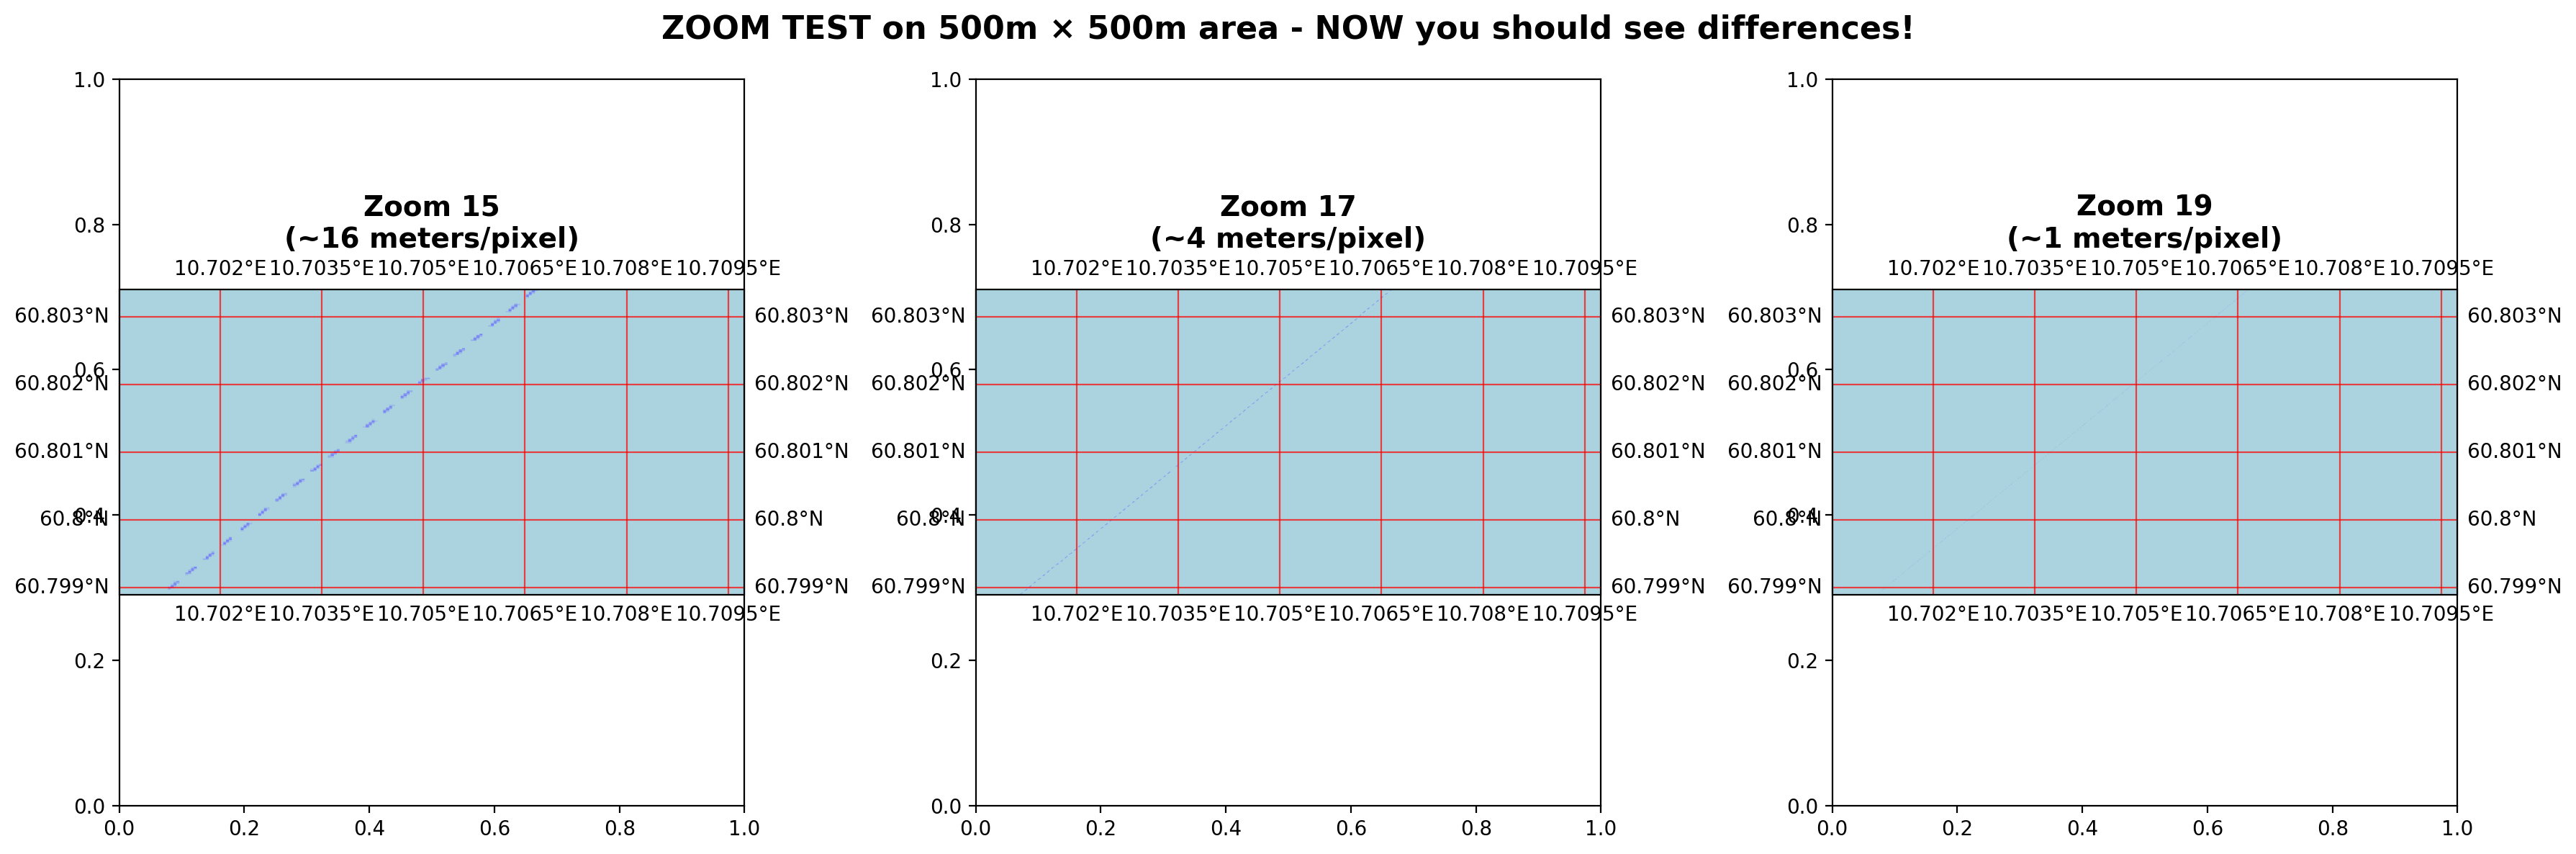


🔍 NOW LOOK CAREFULLY:
   Zoom 15: Blurry/pixelated, few details
   Zoom 17: Sharp, buildings visible, roads clear
   Zoom 19: VERY sharp (if available), individual small features

⚠️ If they STILL look identical:
   1. Your display might be downsampling the image
   2. Save the figure and zoom in with an image viewer
   3. Or the tiles genuinely aren't different (OSM server issue)


In [ ]:
# REAL TEST: Zoom on a TINY area to see actual differences
# The problem: 10km extent is TOO BIG to see zoom differences
# Solution: Test on a 500m × 500m area instead

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import numpy as np

# Small test area - 500 meters around center point
LAT_CENTER = 60.801146
LON_CENTER = 10.705125

# 500m = 0.5km extent
test_extent_km = 0.25  # ±0.25km = 500m × 500m total area

km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.radians(LAT_CENTER))

lat_span = test_extent_km / km_per_deg_lat
lon_span = test_extent_km / km_per_deg_lon

small_extent = [
    LON_CENTER - lon_span,
    LON_CENTER + lon_span,
    LAT_CENTER - lat_span,
    LAT_CENTER + lat_span,
]

print(f"Testing on SMALL area: {test_extent_km*2}km × {test_extent_km*2}km")
print(f"Extent: {small_extent}")

# Test 3 zoom levels
test_zooms = [15, 17, 19]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=200)

for idx, zoom in enumerate(test_zooms):
    ax = plt.subplot(1, 3, idx + 1, projection=ccrs.PlateCarree())

    tile_source = cimgt.OSM()
    ax.set_extent(small_extent, crs=ccrs.PlateCarree())

    print(f"Downloading zoom {zoom}... ", end="")
    try:
        ax.add_image(tile_source, zoom)
        print("✓")
    except Exception as e:
        print(f"FAILED: {e}")

    ax.set_title(
        f"Zoom {zoom}\n(~{2**(19-zoom)} meters/pixel)", fontsize=14, weight="bold"
    )

    # Red grid for visibility
    ax.gridlines(draw_labels=True, linewidth=0.8, color="red", alpha=0.7)

plt.suptitle(
    f"ZOOM TEST on {test_extent_km*2*1000:.0f}m × {test_extent_km*2*1000:.0f}m area - NOW you should see differences!",
    fontsize=16,
    weight="bold",
)
plt.tight_layout()
plt.show()

print("\n🔍 NOW LOOK CAREFULLY:")
print("   Zoom 15: Blurry/pixelated, few details")
print("   Zoom 17: Sharp, buildings visible, roads clear")
print("   Zoom 19: VERY sharp (if available), individual small features")
print("\n⚠️ If they STILL look identical:")
print("   1. Your display might be downsampling the image")
print("   2. Save the figure and zoom in with an image viewer")
print("   3. Or the tiles genuinely aren't different (OSM server issue)")

Testing on HAMAR (city with buildings)
Area: 300m × 300m
Zoom 15... ✓
Zoom 17... ✓
Zoom 19... ✓


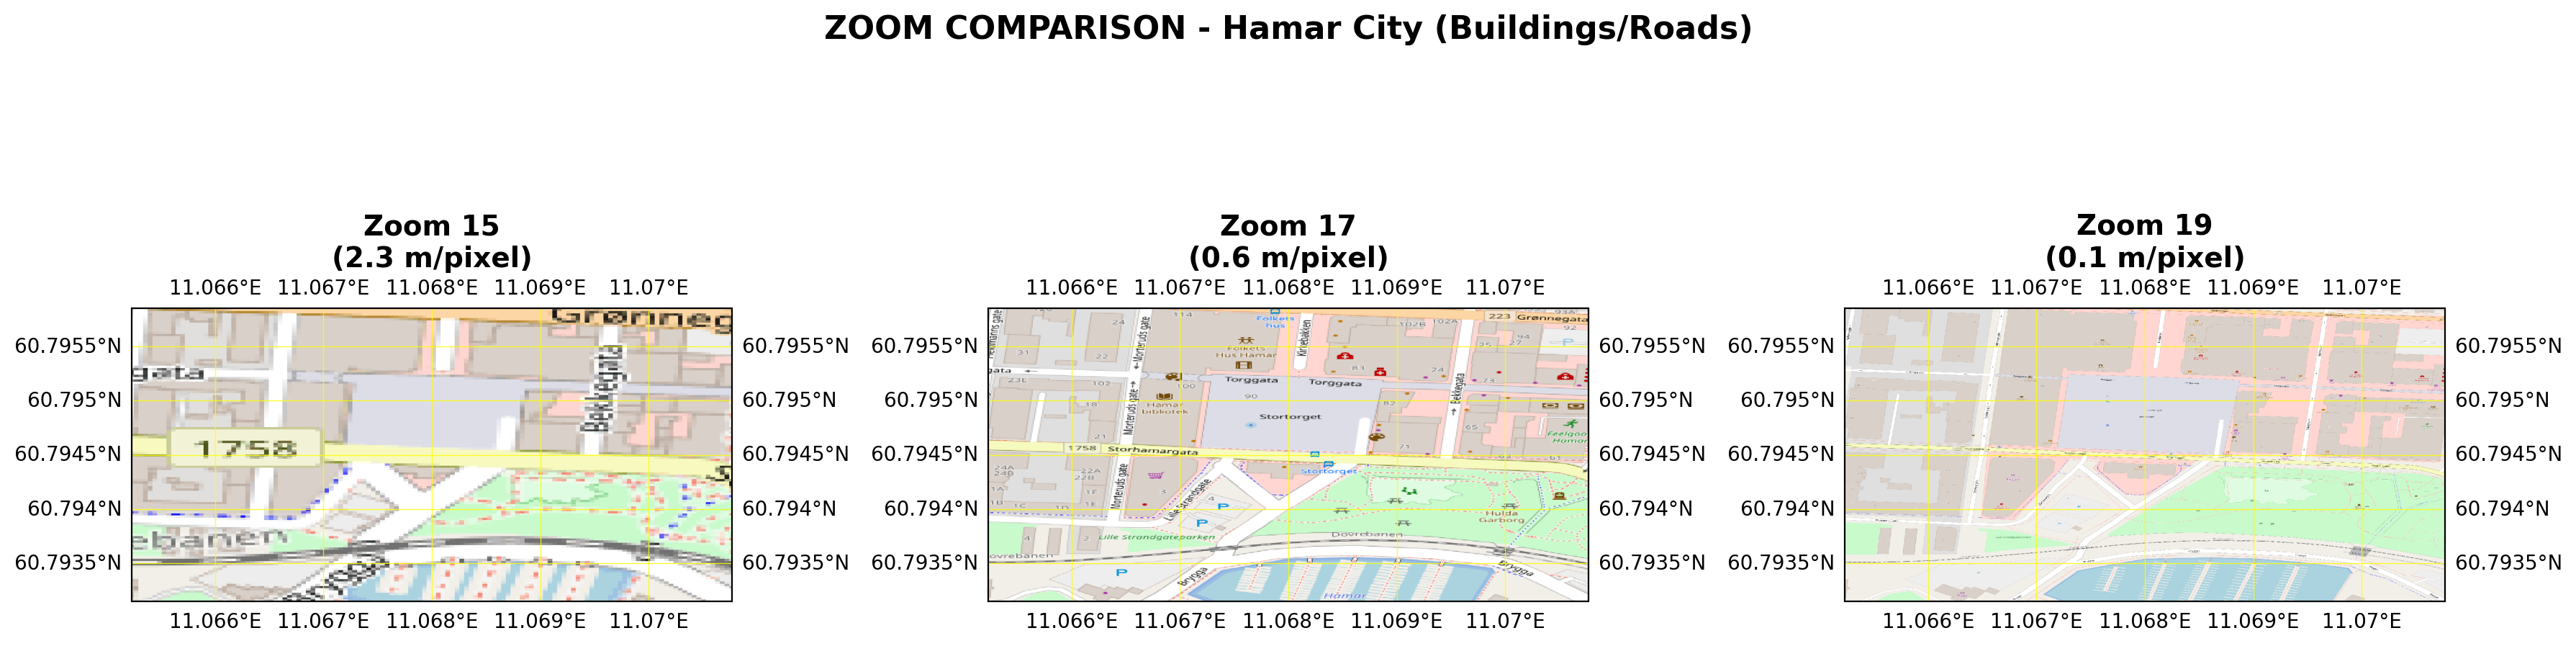


🏙️ NOW you should see REAL differences:
   Zoom 15: Buildings are blobs
   Zoom 17: Buildings have shapes, roads are clear
   Zoom 19: Individual building details, parking lots, small streets

💡 YOUR ORIGINAL MAP is over WATER - that's why zoom doesn't matter!
   Water at zoom 15 = water at zoom 19 = same blue!


In [ ]:
# REAL TEST #2: Test on LAND with buildings to see zoom differences
# Move center to nearby town (Hamar or similar)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import numpy as np

# Test different locations - pick one with buildings/roads
test_locations = {
    "Lake center (your current)": (60.801146, 10.705125),
    "Hamar city (buildings!)": (60.7945, 11.0680),
    "Gjøvik city": (60.7957, 10.6915),
}

# Pick Hamar - has buildings and detail
LAT_TEST = 60.7945
LON_TEST = 11.0680

test_extent_km = 0.15  # Very small: 300m × 300m

km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.radians(LAT_TEST))

lat_span = test_extent_km / km_per_deg_lat
lon_span = test_extent_km / km_per_deg_lon

tiny_extent = [
    LON_TEST - lon_span,
    LON_TEST + lon_span,
    LAT_TEST - lat_span,
    LAT_TEST + lat_span,
]

print(f"Testing on HAMAR (city with buildings)")
print(f"Area: {test_extent_km*2*1000:.0f}m × {test_extent_km*2*1000:.0f}m")

# Compare zoom levels on actual buildings/roads
test_zooms = [15, 17, 19]

fig = plt.figure(figsize=(18, 6), dpi=200)

for idx, zoom in enumerate(test_zooms):
    ax = plt.subplot(1, 3, idx + 1, projection=ccrs.PlateCarree())

    tile_source = cimgt.OSM()
    ax.set_extent(tiny_extent, crs=ccrs.PlateCarree())

    print(f"Zoom {zoom}... ", end="", flush=True)
    try:
        ax.add_image(tile_source, zoom)
        print("✓")
    except Exception as e:
        print(f"✗ {e}")

    # Calculate resolution
    m_per_pixel = 156543.03392 * np.cos(LAT_TEST * np.pi / 180) / (2**zoom)
    ax.set_title(
        f"Zoom {zoom}\n({m_per_pixel:.1f} m/pixel)", fontsize=14, weight="bold"
    )

    ax.gridlines(draw_labels=True, linewidth=0.5, color="yellow", alpha=0.8)

plt.suptitle(
    "ZOOM COMPARISON - Hamar City (Buildings/Roads)", fontsize=16, weight="bold"
)
plt.tight_layout()
plt.show()

print("\n🏙️ NOW you should see REAL differences:")
print("   Zoom 15: Buildings are blobs")
print("   Zoom 17: Buildings have shapes, roads are clear")
print("   Zoom 19: Individual building details, parking lots, small streets")
print("\n💡 YOUR ORIGINAL MAP is over WATER - that's why zoom doesn't matter!")
print("   Water at zoom 15 = water at zoom 19 = same blue!")

## 🎯 IMPORTANT: Understanding "Zoom" vs "Extent"

**You're right to be confused! There are TWO different things:**

1. **EXTENT (geographic zoom)** = How much area you see (like zooming in/out on Google Maps)
   - Controlled by: `ax.set_extent([lon_min, lon_max, lat_min, lat_max])`
   - Example: 10km extent = you see 10km × 10km area
   
2. **TILE ZOOM (image quality)** = How detailed the downloaded tiles are
   - Controlled by: `ax.add_image(tile_source, zoom_level)`
   - Example: zoom 15 = lower quality, zoom 19 = higher quality
   - **BUT**: This does NOT change what geographic area you see!

**The tile zoom parameter is like downloading a photo in different resolutions - the photo shows the same scene, just with more or less detail!**

Extent 10km, tile zoom 17...
Extent 2km, tile zoom 17...
Extent 0.4km, tile zoom 17...


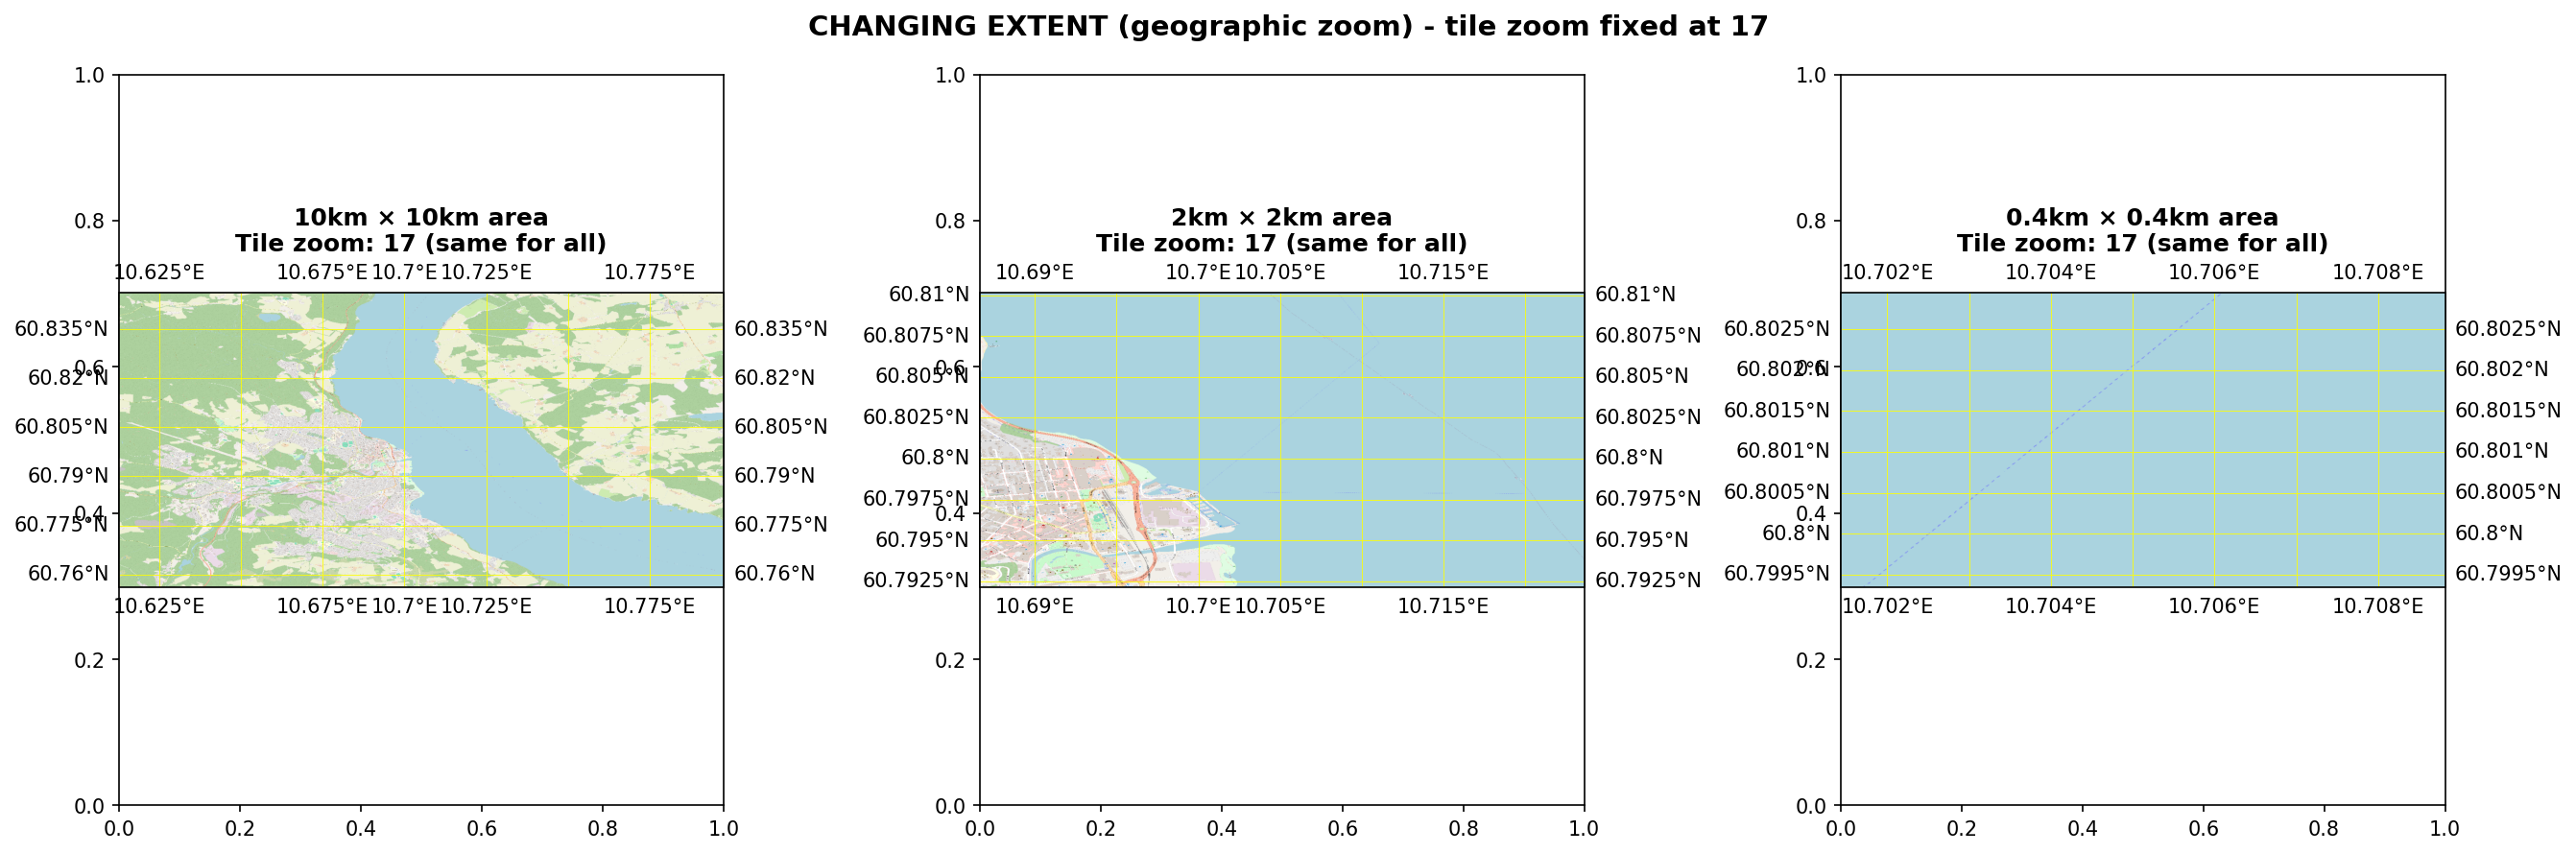


🗺️ EXTENT = What you think of as 'zoom':
   Left: 10km area (zoomed out)
   Middle: 2km area (zoomed in)
   Right: 400m area (VERY zoomed in)

📸 All three use the SAME tile zoom (17)
   → Changing extent = changes what area you SEE
   → Tile zoom = just controls image quality for that area


In [ ]:
# DEMONSTRATION: EXTENT vs TILE ZOOM
# This shows the REAL difference!

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import numpy as np

LAT_CENTER = 60.801146
LON_CENTER = 10.705125

# Test: SAME tile zoom (17), but DIFFERENT extents (geographic zoom)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

test_extents_km = [5, 1, 0.2]  # 10km, 2km, 400m areas

for idx, extent_km in enumerate(test_extents_km):
    ax = plt.subplot(1, 3, idx + 1, projection=ccrs.PlateCarree())

    km_per_deg_lat = 111.0
    km_per_deg_lon = 111.0 * np.cos(np.radians(LAT_CENTER))

    lat_span = extent_km / km_per_deg_lat
    lon_span = extent_km / km_per_deg_lon

    extent = [
        LON_CENTER - lon_span,
        LON_CENTER + lon_span,
        LAT_CENTER - lat_span,
        LAT_CENTER + lat_span,
    ]

    tile_source = cimgt.OSM()
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # ALL using SAME tile zoom (17)
    FIXED_TILE_ZOOM = 17

    print(f"Extent {extent_km*2}km, tile zoom {FIXED_TILE_ZOOM}...")
    ax.add_image(tile_source, FIXED_TILE_ZOOM)

    ax.set_title(
        f"{extent_km*2}km × {extent_km*2}km area\nTile zoom: {FIXED_TILE_ZOOM} (same for all)",
        fontsize=12,
        weight="bold",
    )

    ax.gridlines(draw_labels=True, linewidth=0.5, color="yellow", alpha=0.8)

plt.suptitle(
    "CHANGING EXTENT (geographic zoom) - tile zoom fixed at 17",
    fontsize=14,
    weight="bold",
)
plt.tight_layout()
plt.show()

print("\n🗺️ EXTENT = What you think of as 'zoom':")
print("   Left: 10km area (zoomed out)")
print("   Middle: 2km area (zoomed in)")
print("   Right: 400m area (VERY zoomed in)")
print("\n📸 All three use the SAME tile zoom (17)")
print("   → Changing extent = changes what area you SEE")
print("   → Tile zoom = just controls image quality for that area")

## ✨ FINAL SOLUTION: Easy-to-Use Map Function

**Adjust the parameters in the cell below to create your perfect map!**

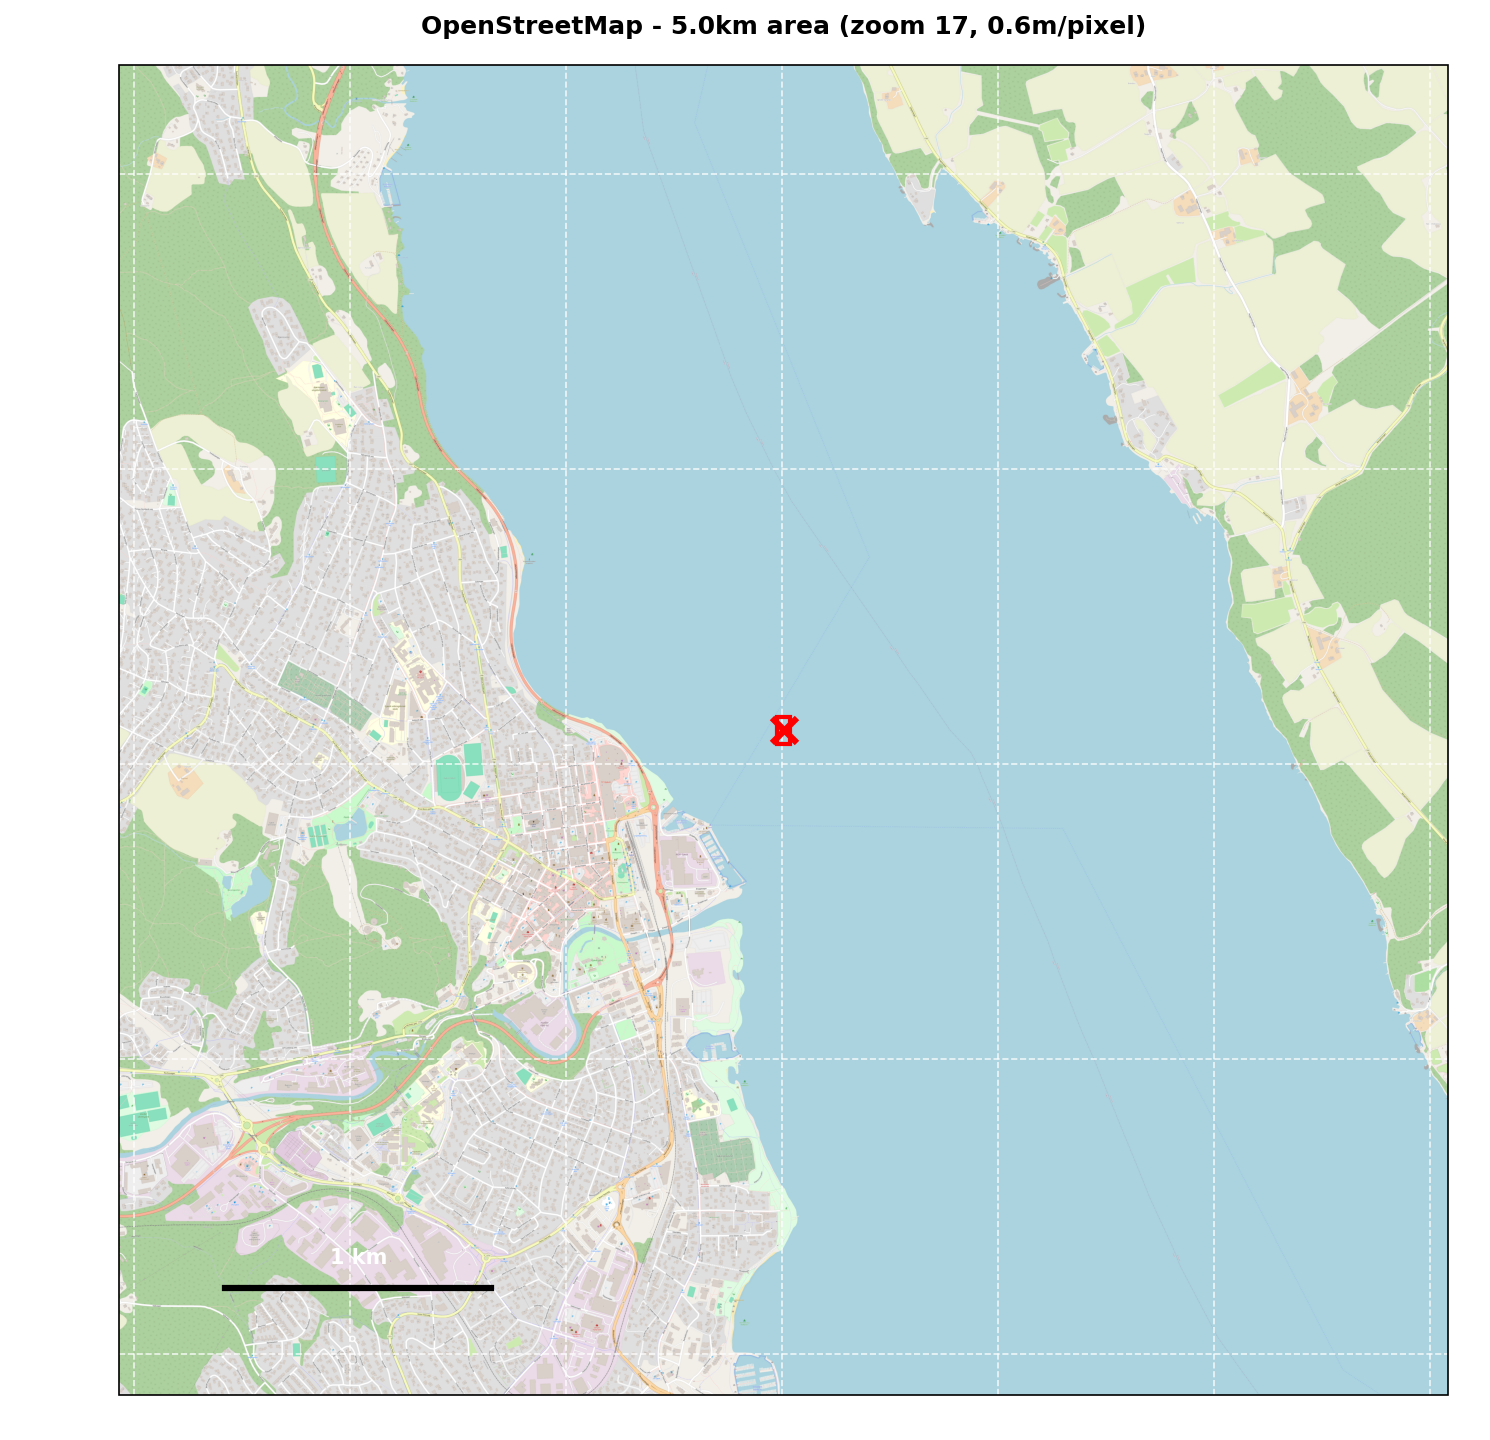

✓ Map created successfully!
  Center: 60.801146°N, 10.705125°E
  Area: 5.0km × 5.0km
  Tile zoom: 17
  Resolution: 0.58 meters/pixel


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import sys
from pathlib import Path

# Import config
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))
from utils.common import config


def create_osm_map(
    lat_center,
    lon_center,
    extent_km=5,
    tile_zoom=17,
    fig_width=8,
    fig_height=8,
    dpi=300,
    show_gridlines=True,
    gridline_color="white",
    scale_bar_km=1,
    show_origin_cross=True,
    show_origin_square=True,
    marker_size=0.006,
    marker_color="red",
    marker_linewidth=2.5,
    title=None,
    save_file=None,
):
    """
    Create an OpenStreetMap with full control over area and detail.

    Parameters:
    -----------
    lat_center, lon_center : float
        Center point of the map (decimal degrees)
    extent_km : float
        Half-width of the map in kilometers (total area = 2×extent_km squared)
        Examples: 5 = 10km×10km, 1 = 2km×2km, 0.5 = 1km×1km
    tile_zoom : int
        OSM tile zoom level (14-19 recommended)
        14 = low detail/fast, 17 = high detail, 19 = very high detail/slow
    fig_width, fig_height : float
        Figure size in inches
    dpi : int
        Resolution (300 = publication quality)
    show_gridlines : bool
        Whether to show gridlines with lat/lon labels (True/False)
    gridline_color : str
        Color for gridlines ('white', 'black', 'red', 'yellow', etc.)
    scale_bar_km : float
        Length of scale bar in kilometers
    show_origin_cross : bool
        Whether to show cross (+) at origin (True/False)
    show_origin_square : bool
        Whether to show square around origin (True/False)
    marker_size : float
        Size of marker relative to map extent (0.006 = default)
    marker_color : str
        Color of marker cross and square ('red', 'blue', 'black', etc.)
    marker_linewidth : float
        Line width for marker cross and square (2.5 = default)
    title : str or None
        Map title (None = auto-generate)
    save_file : str or None
        Filename to save (None = don't save, just display)

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """

    # Calculate extent
    km_per_deg_lat = 111.0
    km_per_deg_lon = 111.0 * np.cos(np.radians(lat_center))

    lat_span = extent_km / km_per_deg_lat
    lon_span = extent_km / km_per_deg_lon

    extent = [
        lon_center - lon_span,  # left
        lon_center + lon_span,  # right
        lat_center - lat_span,  # bottom
        lat_center + lat_span,  # top
    ]

    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    tile_source = cimgt.OSM()
    ax = plt.axes(projection=tile_source.crs)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add map tiles
    print(
        f"Downloading tiles (zoom {tile_zoom}, {extent_km*2}km × {extent_km*2}km area)..."
    )
    ax.add_image(tile_source, tile_zoom)

    # Add gridlines (optional)
    if show_gridlines:
        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.8,
            color=gridline_color,
            alpha=0.8,
            linestyle="--",
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": gridline_color, "weight": "bold"}
        gl.ylabel_style = {"size": 10, "color": gridline_color, "weight": "bold"}
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

    # Scale bar
    scale_lon = scale_bar_km / km_per_deg_lon
    scale_x = extent[0] + 0.08 * (extent[1] - extent[0])
    scale_y = extent[2] + 0.08 * (extent[3] - extent[2])

    # Scale bar (just the black line, no white border)
    ax.plot(
        [scale_x, scale_x + scale_lon],
        [scale_y, scale_y],
        "k-",
        linewidth=3,
        transform=ccrs.PlateCarree(),
        zorder=11,
    )

    # Scale text (no background)
    ax.text(
        scale_x + scale_lon / 2,
        scale_y + 0.015 * (extent[3] - extent[2]),
        f"{scale_bar_km} km",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
        color="white",
        transform=ccrs.PlateCarree(),
        zorder=12,
    )

    # Mark origin point with cross and/or square
    # The cross arms extend half the marker size in each direction
    marker_half_size = marker_size * (extent[1] - extent[0])  # Half-width of cross arms

    if show_origin_cross:
        # Vertical line of cross (|)
        ax.plot(
            [lon_center, lon_center],
            [lat_center - marker_half_size, lat_center + marker_half_size],
            color=marker_color,
            linewidth=marker_linewidth,
            transform=ccrs.PlateCarree(),
            zorder=15,
        )

        # Horizontal line of cross (-)
        ax.plot(
            [lon_center - marker_half_size, lon_center + marker_half_size],
            [lat_center, lat_center],
            color=marker_color,
            linewidth=marker_linewidth,
            transform=ccrs.PlateCarree(),
            zorder=15,
        )

    if show_origin_square:
        # Square with corners at the ends of cross lines
        square = plt.Rectangle(
            (lon_center - marker_half_size, lat_center - marker_half_size),
            2 * marker_half_size,
            2 * marker_half_size,
            fill=False,
            edgecolor=marker_color,
            linewidth=marker_linewidth,
            transform=ccrs.PlateCarree(),
            zorder=14,
        )
        ax.add_patch(square)

    # Title
    if title is None:
        m_per_pixel = 156543.03392 * np.cos(lat_center * np.pi / 180) / (2**tile_zoom)
        title = f"OpenStreetMap - {extent_km*2}km area (zoom {tile_zoom}, {m_per_pixel:.1f}m/pixel)"

    plt.title(title, fontsize=12, pad=15, weight="bold")
    plt.tight_layout()

    # Save if requested
    if save_file:
        plt.savefig(save_file, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"✅ Saved: {save_file}")

    plt.show()

    print(f"✓ Map created successfully!")
    print(f"  Center: {lat_center}°N, {lon_center}°E")
    print(f"  Area: {extent_km*2}km × {extent_km*2}km")
    print(f"  Tile zoom: {tile_zoom}")
    print(f"  Resolution: {m_per_pixel:.2f} meters/pixel")

    return fig, ax


# ============================================================================
# CREATE YOUR MAP - Adjust parameters directly in the function call
# ============================================================================

fig, ax = create_osm_map(
    lat_center=config.LAT0,  # Center latitude
    lon_center=config.LON0,  # Center longitude
    extent_km=2.5,  # Half-width in km (2.5 = 5km×5km map)
    tile_zoom=17,  # 14=fast, 15=good, 17=high, 19=max
    fig_width=10,  # Figure width in inches
    fig_height=10,  # Figure height in inches
    dpi=150,  # Resolution (300=publication, 150=screen)
    show_gridlines=False,  # True/False to show/hide gridlines
    gridline_color="white",  # 'white', 'black', 'red', etc.
    scale_bar_km=1,  # Scale bar length in km
    show_origin_cross=True,  # True/False to show/hide cross
    show_origin_square=True,  # True/False to show/hide square
    marker_size=0.006,  # Marker size (0.006=default, 0.01=larger)
    marker_color="red",  # Marker color ('red', 'blue', 'black', etc.)
    marker_linewidth=2.5,  # Marker line thickness (2.5=default)
    title=None,  # None=auto, or "My Custom Title"
    save_file=None,  # None=don't save, or "map.png"
)

## 🔬 Testing Zoom Limits - Understanding OSM Tile Availability

HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad RequestHTTP Error 400: Bad Request

HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad Request
HTTP Error 400: Bad 

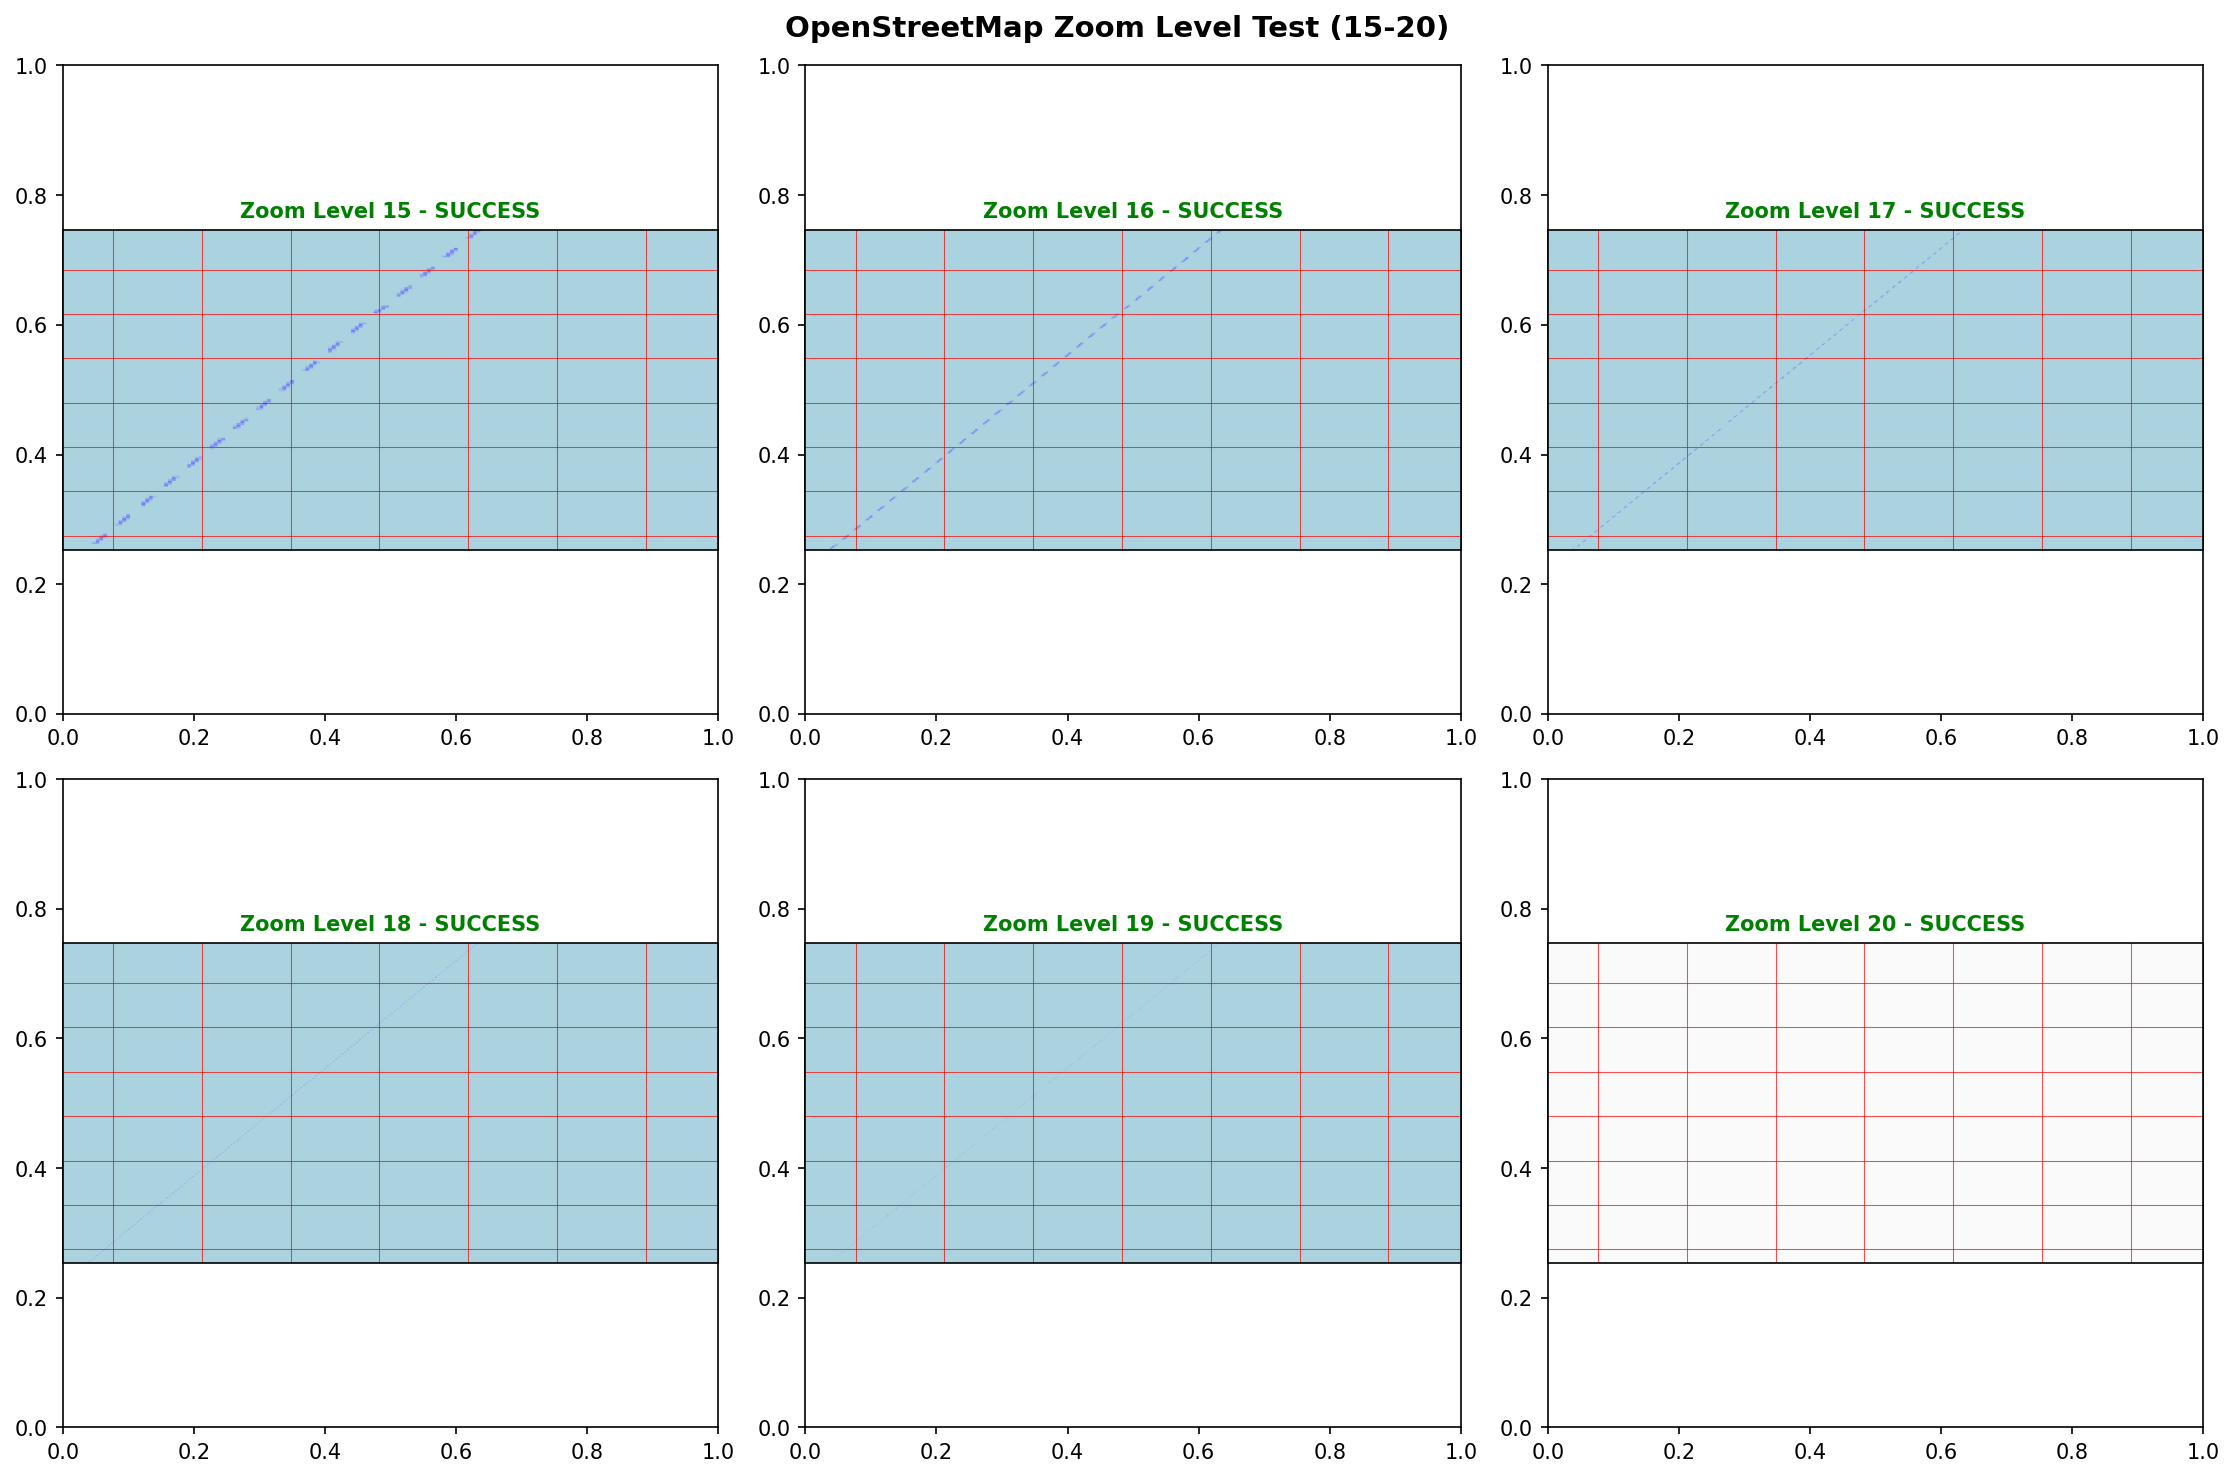

🔍 Zoom Level Test Results:
   - OpenStreetMap standard tiles typically support zoom 0-19
   - Zoom 18-19 may not be available for all areas
   - Cartopy caches tiles, so first load may be slower

📍 Current extent: 0 x 0 km
   Center: 60.801146°N, 10.705125°E


In [14]:
# TEST 1: Try different zoom levels to find the maximum
# OpenStreetMap tiles typically support zoom 0-19, but availability varies

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Test zoom levels from 15 to 20
test_zooms = [15, 16, 17, 18, 19, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=150)
axes = axes.flatten()

for idx, zoom in enumerate(test_zooms):
    ax = plt.subplot(2, 3, idx + 1, projection=ccrs.PlateCarree())
    tile_source = cimgt.OSM()
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    try:
        ax.add_image(tile_source, zoom)
        ax.set_title(
            f"Zoom Level {zoom} - SUCCESS", fontsize=10, weight="bold", color="green"
        )

        # Simple gridlines
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color="red", alpha=0.7)

    except Exception as e:
        ax.text(
            0.5,
            0.5,
            f"Zoom {zoom}\nFAILED\n{str(e)[:50]}",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=8,
        )
        ax.set_title(
            f"Zoom Level {zoom} - FAILED", fontsize=10, weight="bold", color="red"
        )

plt.suptitle("OpenStreetMap Zoom Level Test (15-20)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

print("🔍 Zoom Level Test Results:")
print("   - OpenStreetMap standard tiles typically support zoom 0-19")
print("   - Zoom 18-19 may not be available for all areas")
print("   - Cartopy caches tiles, so first load may be slower")
print(f"\n📍 Current extent: {extent_km*2:.0f} x {extent_km*2:.0f} km")
print(f"   Center: {LAT_CENTER}°N, {LON_CENTER}°E")

In [15]:
# Quick diagnostic - understand zoom levels WITHOUT rendering
# This is STANDALONE - run this cell independently to understand zoom

import math

# Use the values from your map (change these to match your settings)
LAT_CENTER_LOCAL = 60.801146  # From config
LON_CENTER_LOCAL = 10.705125
extent_km_local = 5  # Your current setting


def calculate_tile_resolution(zoom, lat):
    """Calculate meters per pixel at given zoom and latitude"""
    meters_per_pixel = 156543.03392 * math.cos(lat * math.pi / 180) / (2**zoom)
    return meters_per_pixel


def calculate_optimal_zoom(extent_degrees_lon, lat, fig_width_pixels=1050):
    """Calculate optimal zoom based on geographic extent"""
    extent_meters = extent_degrees_lon * 111000 * math.cos(lat * math.pi / 180)
    required_meters_per_pixel = extent_meters / fig_width_pixels
    zoom = math.log2(
        156543.03392 * math.cos(lat * math.pi / 180) / required_meters_per_pixel
    )
    return zoom


# Calculate extent
km_per_deg_lon = 111.0 * math.cos(math.radians(LAT_CENTER_LOCAL))
lon_span = extent_km_local / km_per_deg_lon
lat_span = extent_km_local / 111.0

extent_lon_range = lon_span * 2
extent_lat_range = lat_span * 2

print("🗺️ ZOOM LEVEL ANALYSIS FOR YOUR MAP")
print("=" * 70)
print(f"\n📍 Location: {LAT_CENTER_LOCAL}°N, {LON_CENTER_LOCAL}°E")
print(
    f"📏 Current extent: ±{extent_km_local} km = {extent_km_local*2} km x {extent_km_local*2} km"
)
print(f"   Longitude span: {extent_lon_range:.4f}°")
print(f"   Latitude span: {extent_lat_range:.4f}°")

print("\n🔍 Resolution at different zoom levels:")
print(
    f"{'Zoom':<6} {'m/pixel':<12} {'Total pixels':<15} {'Tile count':<12} {'Status':<20}"
)
print("-" * 70)

for z in range(13, 21):
    m_per_pixel = calculate_tile_resolution(z, LAT_CENTER_LOCAL)
    extent_meters = (
        extent_lon_range * 111000 * math.cos(LAT_CENTER_LOCAL * math.pi / 180)
    )
    pixels_needed = extent_meters / m_per_pixel
    tiles_needed = (pixels_needed / 256) ** 2

    # Status indicator
    if z <= 16:
        status = "✅ Fast & reliable"
    elif z == 17:
        status = "✅ Good (current)"
    elif z == 18:
        status = "⚠️ Slower, OK"
    else:
        status = "❌ Very slow/fails"

    print(
        f"  {z:<6} {m_per_pixel:>10.2f} m  {pixels_needed:>10.0f} px     {tiles_needed:>8.0f} tiles   {status}"
    )

optimal_zoom = calculate_optimal_zoom(extent_lon_range, LAT_CENTER_LOCAL)
print("\n💡 KEY INSIGHTS:")
print(f"   • Optimal zoom for {extent_km_local*2} km extent: ~{optimal_zoom:.1f}")
print(
    f"   • Your current zoom 17: {calculate_tile_resolution(17, LAT_CENTER_LOCAL):.1f} m/pixel"
)
print(
    f"   • At zoom 17, each pixel = {calculate_tile_resolution(17, LAT_CENTER_LOCAL):.1f}m"
)
print(f"   • OpenStreetMap standard tiles max out at zoom 19")

print("\n⚠️ WHY YOU CAN'T ZOOM MORE:")
print(f"   1. OSM tile servers typically max at zoom 19 (sometimes 18)")
print(
    f"   2. At zoom 19: {calculate_tile_resolution(19, LAT_CENTER_LOCAL):.2f} m/pixel"
)
print(f"   3. For {extent_km_local*2} km at zoom 19: {tiles_needed:.0f} tiles needed")
print(f"   4. Downloading {tiles_needed:.0f} tiles takes MINUTES + may hit rate limits")
print(f"   5. Your area (Norway) may not have zoom 19+ available from standard OSM")

print("\n🎯 COMPARISON: Interactive HTML vs Static Matplotlib")
print("\n   ✨ HTML OpenStreetMap (Leaflet/Folium/OpenLayers):")
print("      • Loads tiles ONLY when you pan/zoom to them")
print("      • Can zoom 0-19 smoothly (sometimes 20-21 in cities)")
print("      • Downloads maybe 6-12 tiles at a time for viewport")
print("      • Total data: <1 MB per view")
print("\n   📊 Matplotlib/Cartopy (what you're using):")
print("      • Downloads ALL tiles for ENTIRE extent upfront")
print("      • Must render complete map before showing anything")
print(f"      • At zoom 19 for your area: {tiles_needed:.0f} tiles × 256×256 px each")
print(f"      • Total data: ~{tiles_needed * 20 / 1000:.0f} MB to download!")
print("      • Best practice: use zoom 14-17 for publication maps")

print("\n✅ RECOMMENDATION:")
print(f"   • Your current zoom 17 is EXCELLENT for a {extent_km_local*2}km map")
print(
    f"   • Gives you {calculate_tile_resolution(17, LAT_CENTER_LOCAL):.1f}m resolution"
)
print(f"   • Zoom 18 possible but 4× more tiles = much slower")
print(f"   • Zoom 19+ will likely timeout or take 10+ minutes")
print(f"   • For interactive zooming, use Folium/Leaflet HTML instead!")

🗺️ ZOOM LEVEL ANALYSIS FOR YOUR MAP

📍 Location: 60.801146°N, 10.705125°E
📏 Current extent: ±5 km = 10 km x 10 km
   Longitude span: 0.1847°
   Latitude span: 0.0901°

🔍 Resolution at different zoom levels:
Zoom   m/pixel      Total pixels    Tile count   Status              
----------------------------------------------------------------------
  13           9.32 m        1073 px           18 tiles   ✅ Fast & reliable
  14           4.66 m        2145 px           70 tiles   ✅ Fast & reliable
  15           2.33 m        4291 px          281 tiles   ✅ Fast & reliable
  16           1.17 m        8582 px         1124 tiles   ✅ Fast & reliable
  17           0.58 m       17163 px         4495 tiles   ✅ Good (current)
  18           0.29 m       34326 px        17979 tiles   ⚠️ Slower, OK
  19           0.15 m       68653 px        71917 tiles   ❌ Very slow/fails
  20           0.07 m      137305 px       287669 tiles   ❌ Very slow/fails

💡 KEY INSIGHTS:
   • Optimal zoom for 10 km exte

c:\conda_envs\my_env\lib\site-packages\cartopy\io\img_tiles.py:414: UserWarning: The Stamen styles are no longer served by Stamen and are now served by Stadia Maps. Please use the StadiaMapsTiles class instead.
  warnings.warn("The Stamen styles are no longer served by Stamen and "


<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>


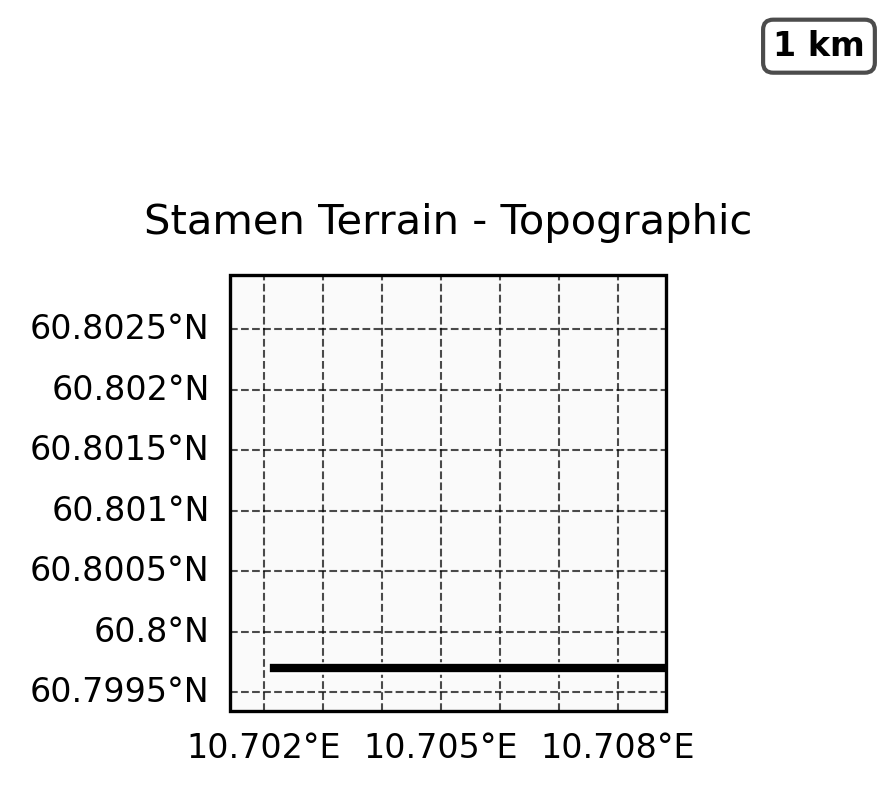

In [16]:
# Option 2: Stamen Terrain - topographic style
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = cimgt.Stamen("terrain-background")
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_image(tile_source, 15)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    color="black",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
)

plt.title("Stamen Terrain - Topographic", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

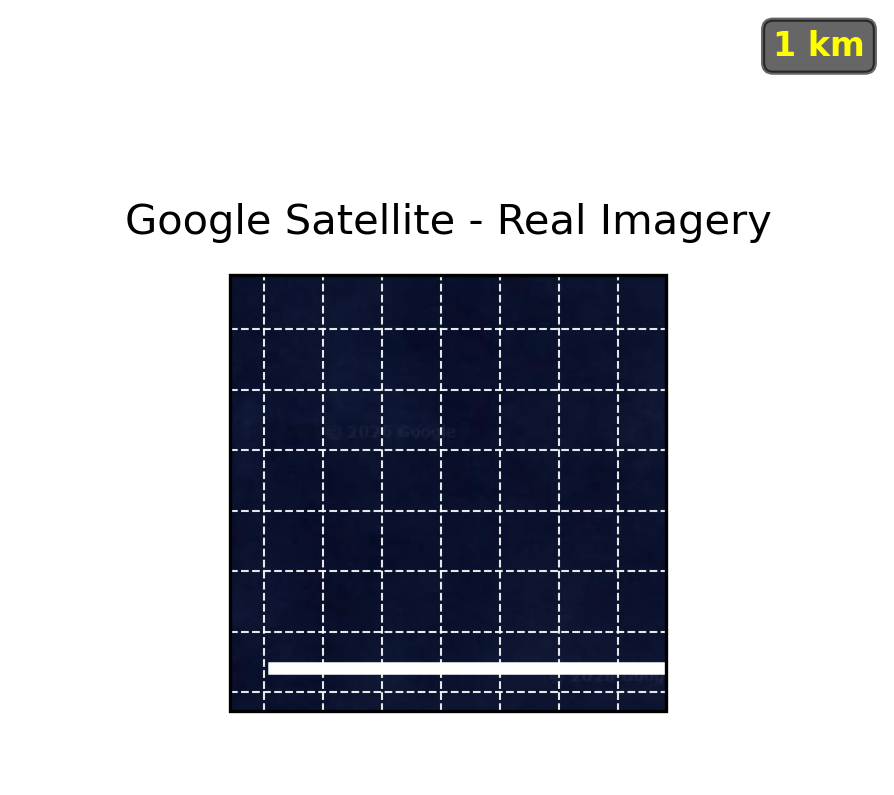

In [17]:
# Option 3: Google Tiles (satellite imagery)
class GoogleTiles(cimgt.GoogleWTS):
    def _image_url(self, tile):
        x, y, z = tile
        url = f"https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"
        return url


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = GoogleTiles()
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_image(tile_source, 16)  # Higher zoom for satellite

# Add gridlines (white for satellite)
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="white", alpha=0.9, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8, "color": "white"}
gl.ylabel_style = {"size": 8, "color": "white"}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    color="yellow",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.6),
)

plt.title("Google Satellite - Real Imagery", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Publication-Ready Offline Map (No Internet Required)
Clean, high-resolution map using only cartopy's built-in Natural Earth data

NameError: name 'cfeature' is not defined

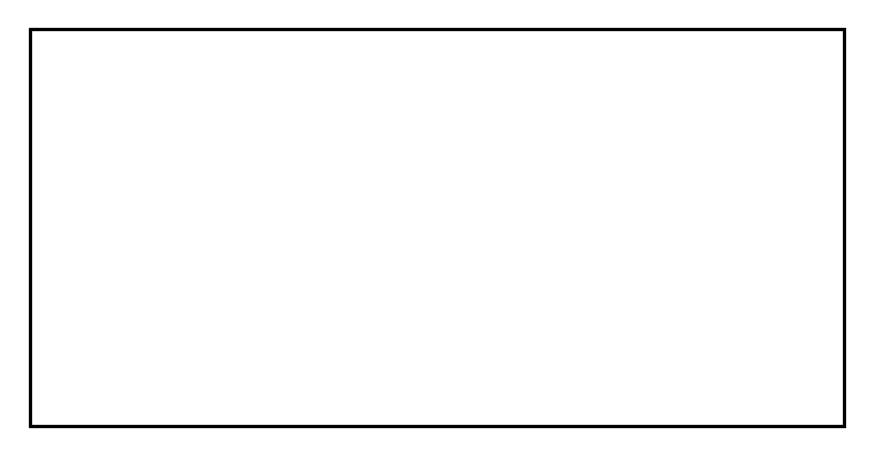

In [18]:
# Clean publication map - all land same color, high resolution
# Uses Natural Earth 10m data (open source, offline, publication-quality)

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Single color land with detailed coastlines (10m = highest resolution)
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.8,
)

# Water features
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")

ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="white",
    edgecolor="black",
    linewidth=0.5,
)

# Add rivers for context
ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="black", linewidth=0.3)

# Clean gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.title("Publication Map - High Resolution (10m)", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

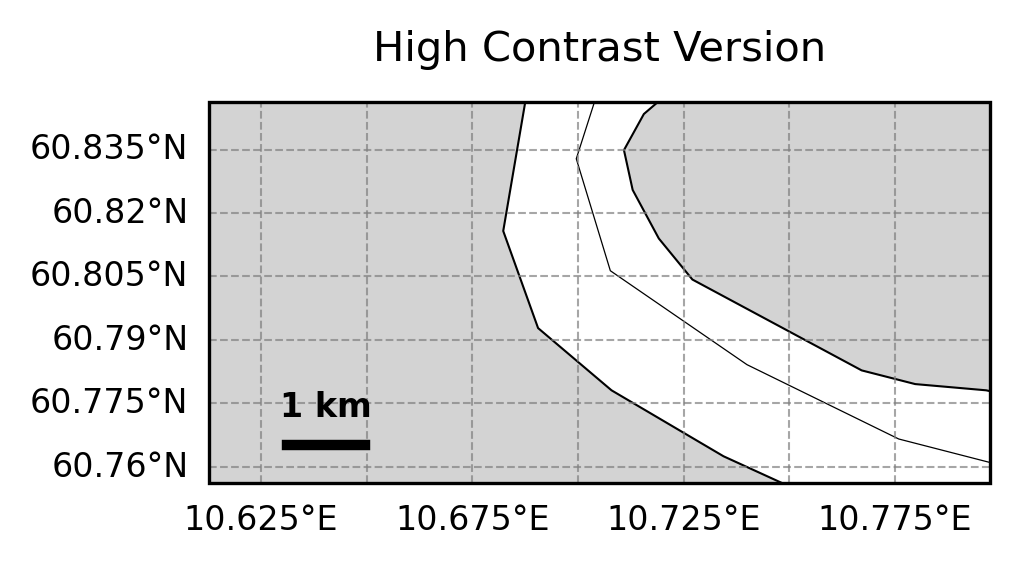

In [ ]:
# Alternative: Darker land for better contrast
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Darker gray land
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="#D3D3D3",  # Darker gray
    edgecolor="black",
    linewidth=0.8,
)

ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white")

ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="white",
    edgecolor="black",
    linewidth=0.5,
)

ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="black", linewidth=0.3)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.title("High Contrast Version", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

✓ Saved: mjosa_sampling_site_5km.pdf
  Resolution: 300 DPI
  Format: PDF
  Data source: Natural Earth 10m (open source, CC0 license)


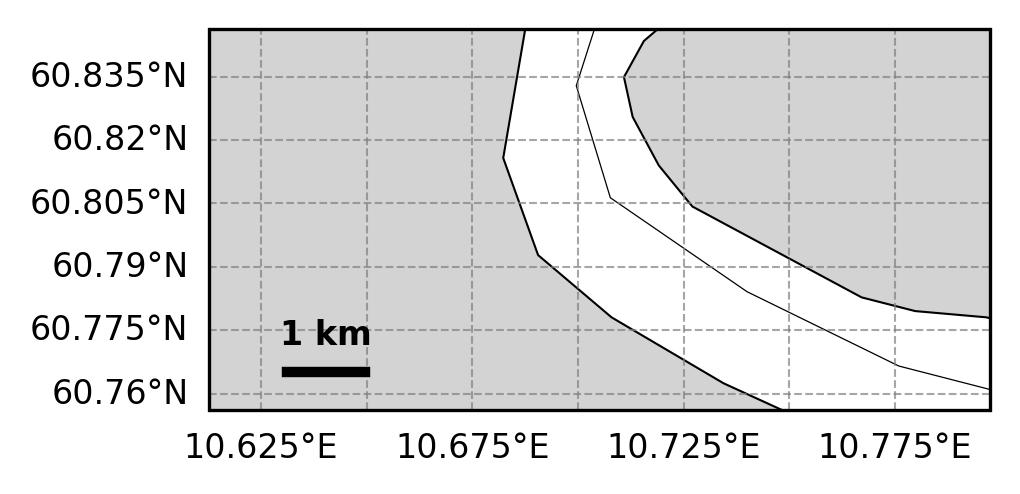

In [ ]:
# Export final publication version
# Set parameters and run this cell to save

FINAL_EXTENT_KM = 5  # Choose zoom level (2 for 4x4 km, 5 for 10x10 km, etc.)
LAND_COLOR = "lightgray"  # or '#D3D3D3' for darker, or 'wheat', '#E0E0E0'
OUTPUT_FORMAT = (
    "pdf"  # 'pdf' recommended for publications (vector), or 'png', 'svg', 'tiff'
)
OUTPUT_DPI = 300

# Calculate extent
lat_span = FINAL_EXTENT_KM / km_per_deg_lat
lon_span = FINAL_EXTENT_KM / km_per_deg_lon
final_extent = [
    LON_CENTER - lon_span,
    LON_CENTER + lon_span,
    LAT_CENTER - lat_span,
    LAT_CENTER + lat_span,
]

# Create figure
fig = plt.figure(figsize=(3.5, 3.5), dpi=OUTPUT_DPI)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(final_extent, crs=ccrs.PlateCarree())

# Add features (10m = highest resolution Natural Earth data)
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor=LAND_COLOR,
    edgecolor="black",
    linewidth=0.8,
)

ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white")

ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="white",
    edgecolor="black",
    linewidth=0.5,
)

ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="black", linewidth=0.3)

# Gridlines with coordinates
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = final_extent[0] + 0.1 * (final_extent[1] - final_extent[0])
scale_y = final_extent[2] + 0.1 * (final_extent[3] - final_extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.tight_layout()

# Save
output_file = f"mjosa_sampling_site_{FINAL_EXTENT_KM}km.{OUTPUT_FORMAT}"
plt.savefig(output_file, dpi=OUTPUT_DPI, bbox_inches="tight", facecolor="white")
print(f"✓ Saved: {output_file}")
print(f"  Resolution: {OUTPUT_DPI} DPI")
print(f"  Format: {OUTPUT_FORMAT.upper()}")
print(f"  Data source: Natural Earth 10m (open source, CC0 license)")
plt.show()

## BEST OPTION: High-Res Stamen Toner Lite (Clean, No Labels)
Stamen Toner Lite provides clean land outlines without street names - perfect for publications

c:\conda_envs\my_env\lib\site-packages\cartopy\io\img_tiles.py:414: UserWarning: The Stamen styles are no longer served by Stamen and are now served by Stadia Maps. Please use the StadiaMapsTiles class instead.
  warnings.warn("The Stamen styles are no longer served by Stamen and "


<urlopen error [Errno 11001] getaddrinfo failed><urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>

<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errn

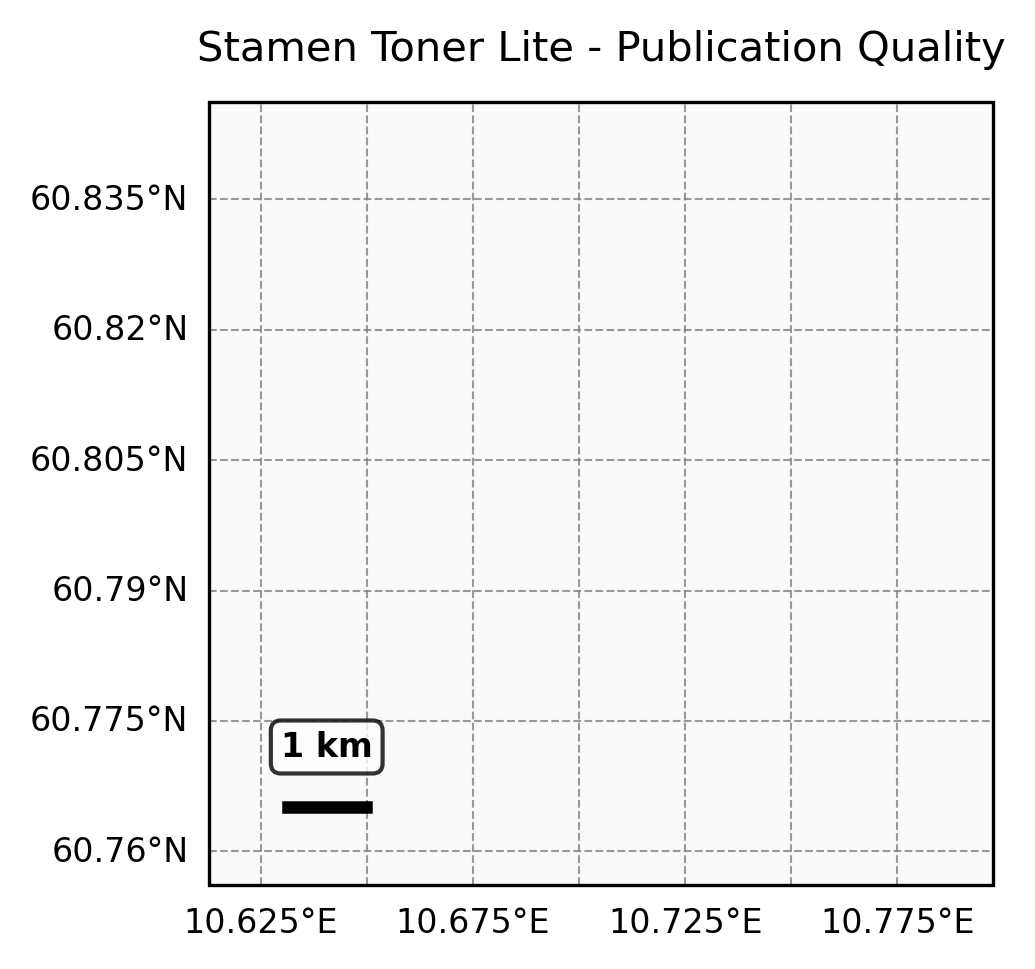

✓ Stamen Toner Lite: Clean B&W map, no labels, high detail
  License: CC BY 3.0 (open source, attribution required)
  Resolution: ~2-5 meters at this zoom level


In [ ]:
# Stamen Toner Lite - Clean black/white map with detailed coastlines, NO labels
# This is MUCH higher resolution than Natural Earth 10m data
# Open source (CC BY 3.0), suitable for publications

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = cimgt.Stamen("toner-lite")  # 'toner-lite' = clean, no labels
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Zoom level 16 = ~1-5 meter resolution (very high detail)
ax.add_image(tile_source, 16)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.8, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

plt.title("Stamen Toner Lite - Publication Quality", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

print("✓ Stamen Toner Lite: Clean B&W map, no labels, high detail")
print("  License: CC BY 3.0 (open source, attribution required)")
print("  Resolution: ~2-5 meters at this zoom level")

## Option A: Natural Earth with Proper Attribution
Free to use, public domain equivalent, good for overview maps

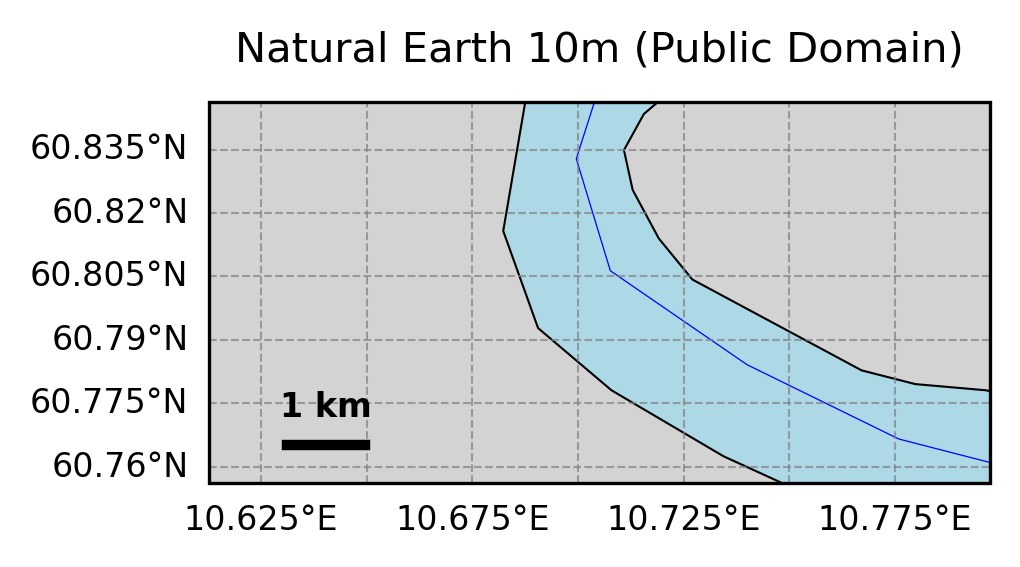

Data source: Natural Earth 10m
License: Public domain equivalent
Attribution: Optional (can cite naturalearthdata.com in Methods)


In [ ]:
# Natural Earth 10m - Best available offline resolution
# License: Public domain equivalent, no attribution required (but can cite in Methods)

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Background color
ax.set_facecolor("white")

# Add features in order: ocean, land, lakes
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="lightblue", zorder=0)
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.8,
    zorder=1,
)
ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.5,
    zorder=2,
)
ax.add_feature(
    cfeature.RIVERS.with_scale("10m"), edgecolor="blue", linewidth=0.3, zorder=2
)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.title("Natural Earth 10m (Public Domain)", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

print("Data source: Natural Earth 10m")
print("License: Public domain equivalent")
print("Attribution: Optional (can cite naturalearthdata.com in Methods)")

## Option B: Kartverket N50 (Highest Detail for Norway)
Best accuracy for Norwegian lakes/coastlines - requires download from data.norge.no

In [ ]:
# Download instructions for Kartverket N50:
# 1. Go to: https://kartkatalog.geonorge.no/metadata/n50-kartdata/ea192681-d039-42ec-b1bc-f3ce04c189ac
# 2. Download "N50 Kartdata" (GeoPackage or Shapefile format)
# 3. Extract water polygons layer (Vann / Water)
# 4. Save path below

# Example code (uncomment and edit path when you have the data):
"""
import geopandas as gpd

# Load Kartverket N50 water polygons
kartverket_water = gpd.read_file("path/to/N50_Vann.gpkg", layer="vann")
kartverket_water = kartverket_water.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=300)
ax.set_facecolor('lightgray')  # Land color

# Clip to extent
kartverket_water_clip = kartverket_water.cx[extent[0]:extent[1], extent[2]:extent[3]]

# Plot water
kartverket_water_clip.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)

# Set extent
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Add gridlines (manual for matplotlib axes)
ax.grid(True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
ax.set_xlabel('Longitude (°E)', fontsize=8)
ax.set_ylabel('Latitude (°N)', fontsize=8)
ax.tick_params(labelsize=8)

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot([scale_x, scale_x + scale_lon], [scale_y, scale_y], 'k-', linewidth=2.5)
ax.text(scale_x + scale_lon/2, scale_y + 0.005, f'{scale_km} km',
        ha='center', va='bottom', fontsize=8, weight='bold')

plt.title('Kartverket N50 (High Detail Norway)', fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('kartverket_map.pdf')
plt.show()

print("Data source: Kartverket N50 Kartdata")
print("License: Open data (Norge digitalt)")
print("Attribution: 'Data from Kartverket' in caption or methods")
"""

print("⚠ Kartverket N50 requires manual download")
print(
    "📥 Download from: https://kartkatalog.geonorge.no/metadata/n50-kartdata/ea192681-d039-42ec-b1bc-f3ce04c189ac"
)
print("📁 Look for water polygons layer (Vann)")
print("✏️ Uncomment code above and set file path")

⚠ Kartverket N50 requires manual download
📥 Download from: https://kartkatalog.geonorge.no/metadata/n50-kartdata/ea192681-d039-42ec-b1bc-f3ce04c189ac
📁 Look for water polygons layer (Vann)
✏️ Uncomment code above and set file path


## Option C: HydroLAKES (Global Lake Database)
High-accuracy lake polygons, CC BY 4.0 license (attribution required)

In [ ]:
# Download instructions for HydroLAKES:
# 1. Go to: https://www.hydrosheds.org/products/hydrolakes
# 2. Register and download HydroLAKES database
# 3. Extract Lake Mjøsa polygon (by name or coordinates)

# Example code (uncomment when you have the data):
"""
import geopandas as gpd

# Load HydroLAKES
hydrolakes = gpd.read_file("path/to/HydroLAKES.shp")
hydrolakes = hydrolakes.to_crs("EPSG:4326")

# Find Lake Mjøsa (by name or bounding box)
mjosa = hydrolakes[hydrolakes['Lake_name'] == 'Mjøsa']  # or use spatial filter

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=300)
ax.set_facecolor('lightgray')  # Land

# Plot Mjøsa
mjosa.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.grid(True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
ax.set_xlabel('Longitude (°E)', fontsize=8)
ax.set_ylabel('Latitude (°N)', fontsize=8)

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot([scale_x, scale_x + scale_lon], [scale_y, scale_y], 'k-', linewidth=2.5)
ax.text(scale_x + scale_lon/2, scale_y + 0.005, f'{scale_km} km',
        ha='center', va='bottom', fontsize=8, weight='bold')

plt.title('HydroLAKES - Lake Mjøsa', fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('hydrolakes_map.pdf')
plt.show()

print("Data source: HydroLAKES")
print("License: CC BY 4.0")
print("Attribution REQUIRED: 'HydroLAKES (Messager et al., 2016)' in caption")
"""

print("⚠ HydroLAKES requires registration and download")
print("📥 Download from: https://www.hydrosheds.org/products/hydrolakes")
print("📄 License: CC BY 4.0 - MUST attribute in caption")
print("✏️ Uncomment code above and set file path")

⚠ HydroLAKES requires registration and download
📥 Download from: https://www.hydrosheds.org/products/hydrolakes
📄 License: CC BY 4.0 - MUST attribute in caption
✏️ Uncomment code above and set file path


## Summary: Which Option to Use?

| Option | Resolution | License | Attribution | Best For |
|--------|-----------|---------|-------------|----------|
| **Natural Earth 10m** | ~10m accuracy | Public domain | Optional | Quick overview maps |
| **Kartverket N50** | ~1m accuracy | Open data | Credit Kartverket | Detailed Norway maps |
| **HydroLAKES** | High accuracy lakes | CC BY 4.0 | **Required** | Lake-focused studies |
| **OSM tiles** | Very high | ODbL | **Required** | Online maps only |

# 🗺️ OpenStreetMap High-Detail Maps (Drawn Style)

The cells above use **OpenStreetMap's rendered/drawn tiles** - this shows:
- **Roads** (highways, streets, paths)
- **Buildings** (footprints and labels)
- **Land use** (forests, parks, water)
- **Labels** (place names, features)
- **Topography** (rendered in cartographic style)

This is **NOT satellite imagery** - it's a **drawn/vector-style map** like traditional paper maps.

## What you get:
- ✅ Detailed cartographic rendering (like Google Maps default view)
- ✅ Very high zoom levels available (up to 19)  
- ✅ Shows roads, buildings, land features
- ✅ Includes place names and labels
- ❌ Requires internet to download tiles
- ❌ Not suitable for offline use

## Alternative styles:
- `cimgt.OSM()` = **Standard drawn map** (roads, buildings, labels)
- `cimgt.Stamen('toner-lite')` = **Clean B&W** (no labels, minimal style)
- `cimgt.Stamen('terrain')` = **Topographic** (elevation shading)
- `GoogleTiles()` = **Satellite imagery** (aerial photos)

## For publication use:
- **OSM drawn style**: Good for showing context (roads, settlements)
- **Stamen Toner Lite**: Clean, minimal, no distracting labels
- **Natural Earth offline**: Best for publication (no internet, public domain)

**Attribution required**: "Map data © OpenStreetMap contributors"


Center coordinates:
  WGS84: 60.801146°N, 10.705125°E
  UTM 32N: 592791.89m E, 6741843.85m N


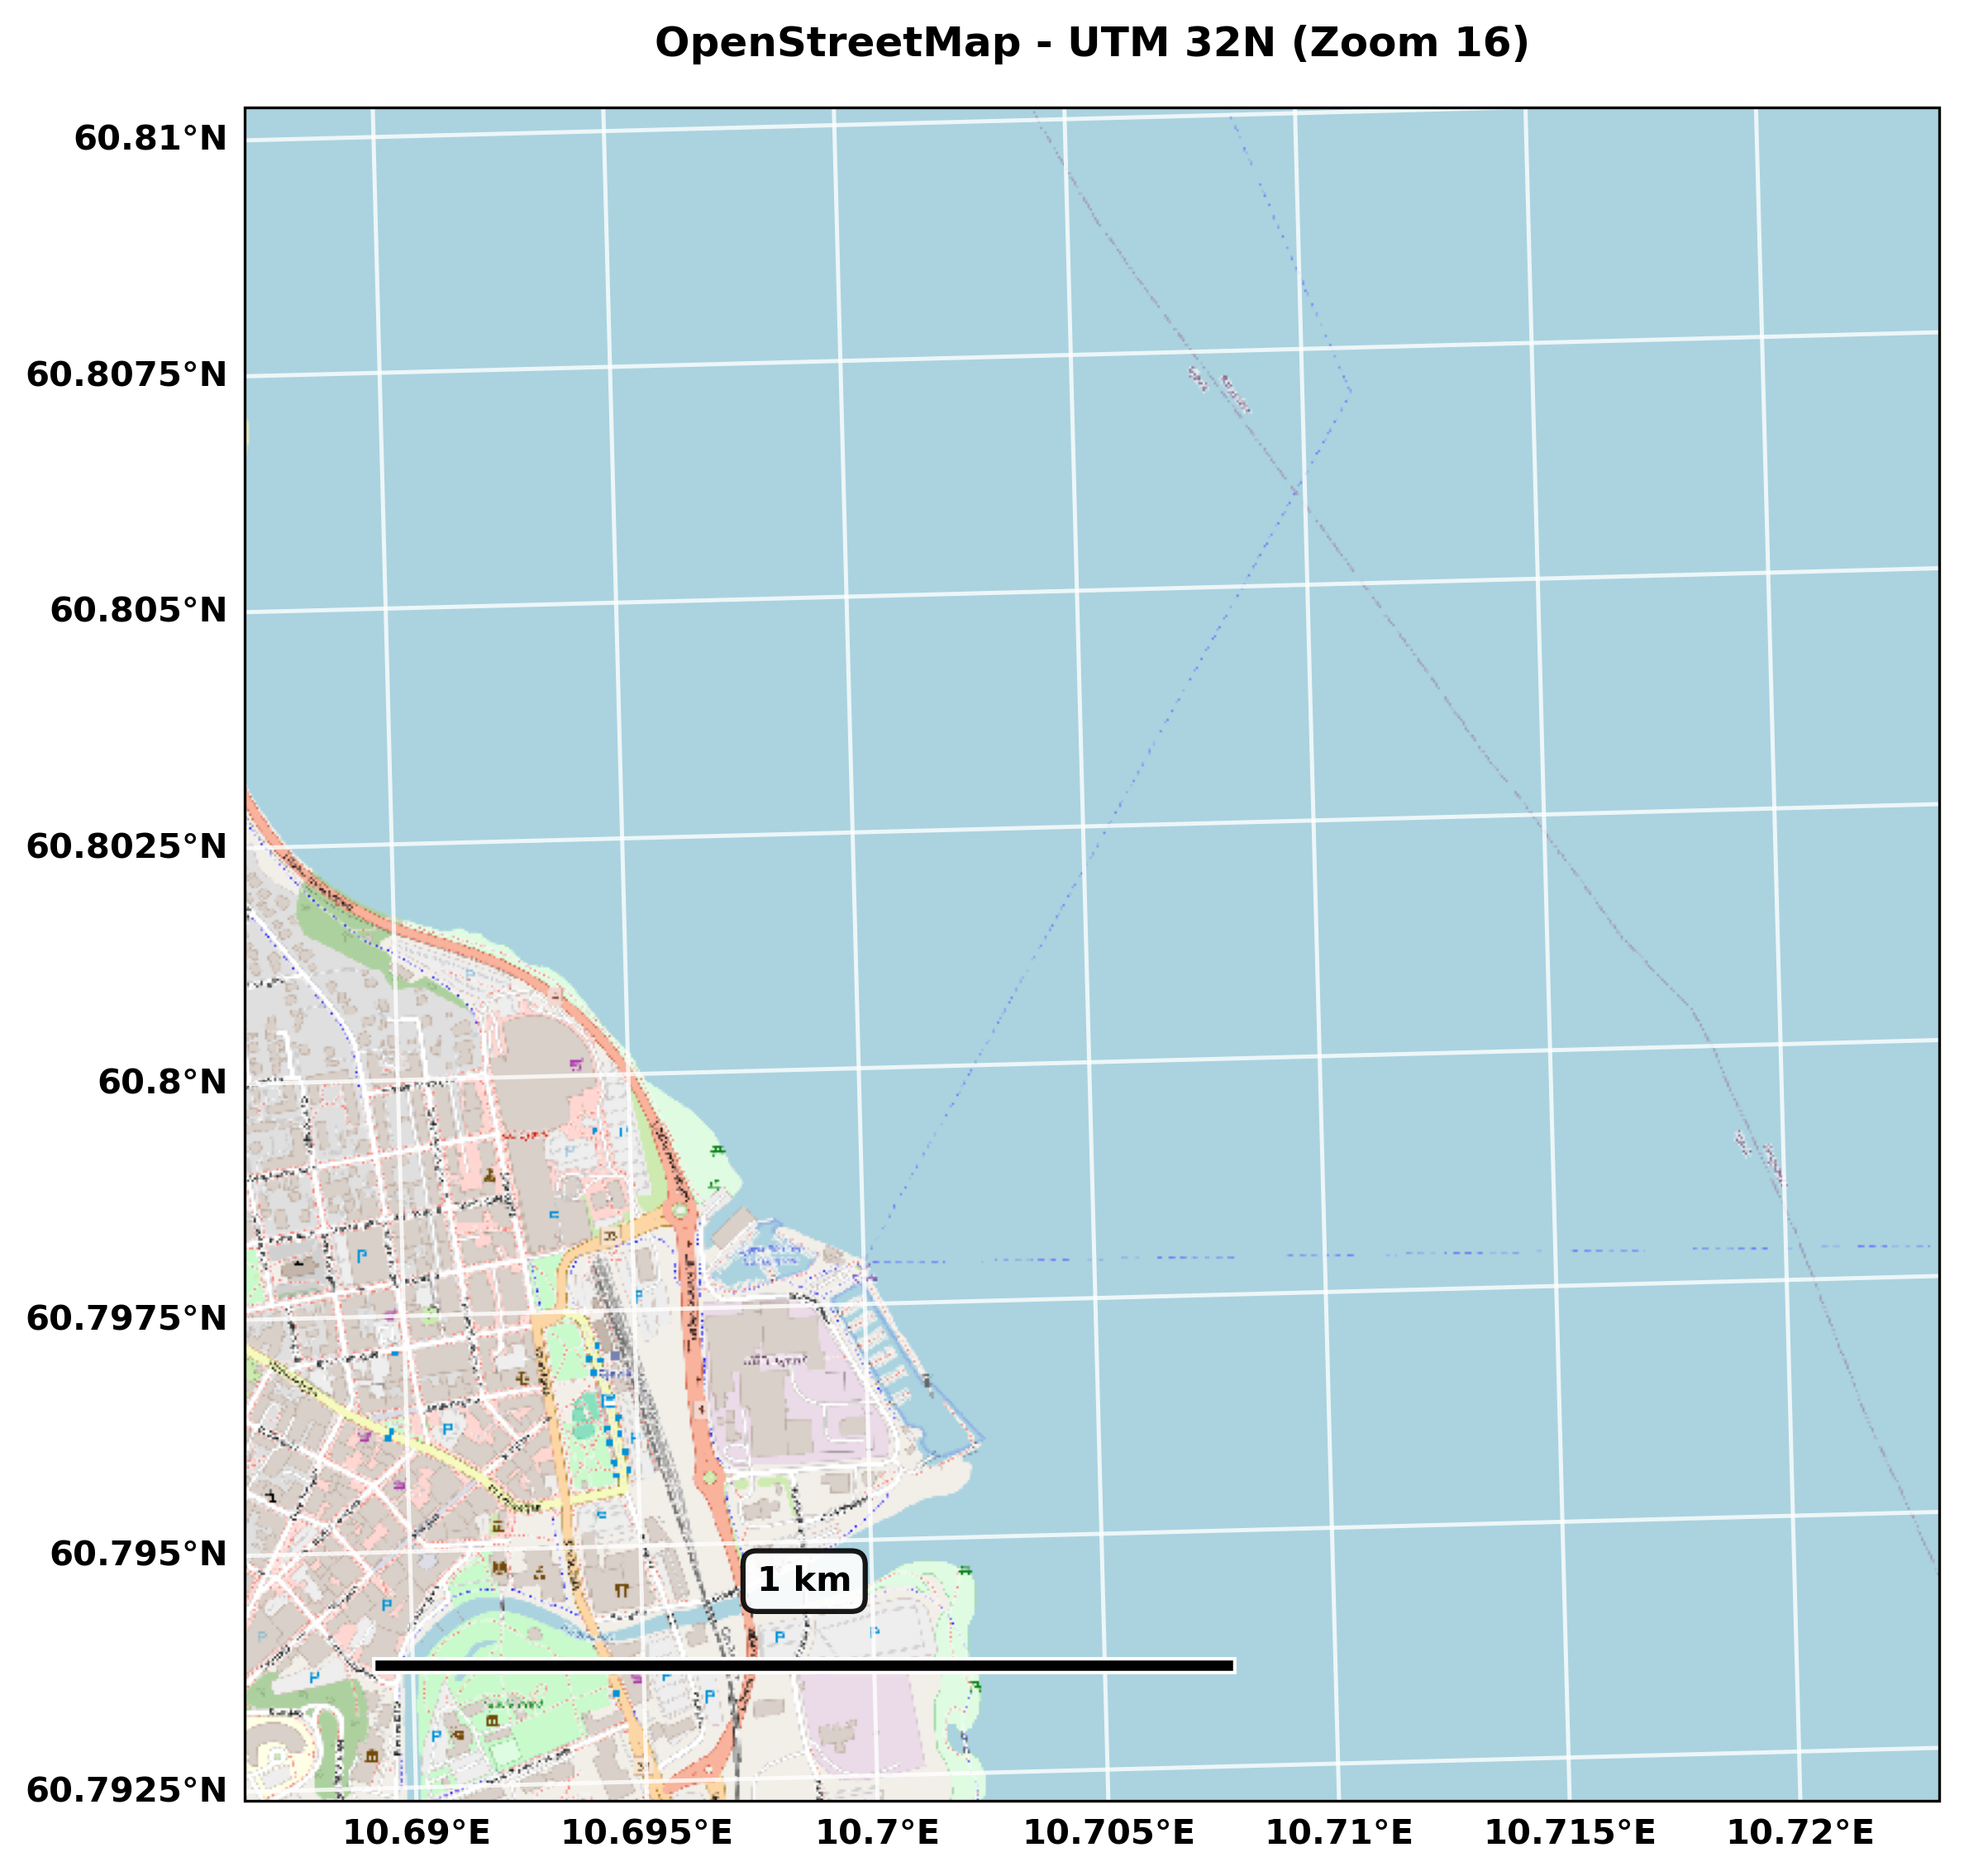

✓ OpenStreetMap DRAWN style with UTM 32N projection
  Zoom level: 16 (~2-5 meter resolution)
  Map extent: 2 x 2 km
  Projection: UTM Zone 32N (EPSG:32632) - EXACT, no approximations
  License: © OpenStreetMap contributors (ODbL)
  Attribution: 'Map data © OpenStreetMap contributors' required

🔧 Adjust ZOOM_LEVEL: 14=overview, 16=detailed, 17=very detailed
🔧 Adjust EXTENT_KM: smaller = more zoomed in


In [ ]:
# HIGH-DETAIL OPENSTREETMAP (DRAWN STYLE) - UTM 32N (MOST ACCURATE)
# This cell contains ALL necessary code - just run this one cell!
# Uses UTM Zone 32N projection - no approximations, direct meter calculations

# Imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
from pyproj import Transformer

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))

from utils.common import config

# Map center (Lake Mjøsa, Norway) - from config
LAT_CENTER = config.LAT0  # 60.801146°N
LON_CENTER = config.LON0  # 10.705125°E

# Convert WGS84 (lat/lon) to UTM 32N (meters) - EXACT conversion
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
UTM_EASTING, UTM_NORTHING = transformer.transform(LON_CENTER, LAT_CENTER)

print(f"Center coordinates:")
print(f"  WGS84: {LAT_CENTER}°N, {LON_CENTER}°E")
print(f"  UTM 32N: {UTM_EASTING:.2f}m E, {UTM_NORTHING:.2f}m N")

# Map extent in meters (NO approximations!)
EXTENT_KM = 1  # Coverage: 1 km = 2x2 km map (zoomed in on origin!)
EXTENT_METERS = EXTENT_KM * 1000  # Convert to meters

extent_utm = [
    UTM_EASTING - EXTENT_METERS,  # left
    UTM_EASTING + EXTENT_METERS,  # right
    UTM_NORTHING - EXTENT_METERS,  # bottom
    UTM_NORTHING + EXTENT_METERS,  # top
]

# UTM 32N projection (accurate for 6°E to 12°E)
utm_crs = ccrs.UTM(zone=32, southern_hemisphere=False)

# Create figure with OpenStreetMap tiles (DRAWN/RENDERED style)
fig = plt.figure(figsize=(8, 8), dpi=300)  # Larger for detail
tile_source = cimgt.OSM()  # This is the DRAWN map style (not satellite!)
ax = plt.axes(projection=utm_crs)
ax.set_extent(extent_utm, crs=utm_crs)

# Add tiles at high zoom level
# Zoom level 16-17 = very high detail (~1-5 meter resolution)
# Higher zoom = more detail but slower download
ZOOM_LEVEL = 16  # Adjust: 14=less detail/faster, 17=more detail/slower

ax.add_image(tile_source, ZOOM_LEVEL)

# Clean gridlines with UTM coordinates
gl = ax.gridlines(
    draw_labels=True,
    linewidth=1.2,
    color="white",  # White gridlines
    alpha=0.8,
    linestyle="-",
    crs=ccrs.PlateCarree(),  # Show lat/lon labels on UTM projection
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10, "color": "black", "weight": "bold"}
gl.ylabel_style = {"size": 10, "color": "black", "weight": "bold"}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar in UTM meters (EXACT, no approximations!)
scale_meters = 1000  # 1 km = 1000 m
scale_x = extent_utm[0] + 0.08 * (extent_utm[1] - extent_utm[0])
scale_y = extent_utm[2] + 0.08 * (extent_utm[3] - extent_utm[2])

# White outline
ax.plot(
    [scale_x, scale_x + scale_meters],
    [scale_y, scale_y],
    "w-",
    linewidth=5,
    transform=utm_crs,
    zorder=10,
)
# Black bar
ax.plot(
    [scale_x, scale_x + scale_meters],
    [scale_y, scale_y],
    "k-",
    linewidth=3,
    transform=utm_crs,
    zorder=11,
)

# Scale text with white background
ax.text(
    scale_x + scale_meters / 2,
    scale_y + 80,  # Offset in meters
    f"{scale_meters/1000:.0f} km",
    ha="center",
    va="bottom",
    fontsize=10,
    weight="bold",
    transform=utm_crs,
    zorder=12,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        alpha=0.9,
    ),
)

plt.title(
    f"OpenStreetMap - UTM 32N (Zoom {ZOOM_LEVEL})",
    fontsize=12,
    pad=15,
    weight="bold",
)
plt.tight_layout()
plt.show()

print("✓ OpenStreetMap DRAWN style with UTM 32N projection")
print(f"  Zoom level: {ZOOM_LEVEL} (~2-5 meter resolution)")
print(f"  Map extent: {EXTENT_KM*2:.0f} x {EXTENT_KM*2:.0f} km")
print(f"  Projection: UTM Zone 32N (EPSG:32632) - EXACT, no approximations")
print("  License: © OpenStreetMap contributors (ODbL)")
print("  Attribution: 'Map data © OpenStreetMap contributors' required")
print("\n🔧 Adjust ZOOM_LEVEL: 14=overview, 16=detailed, 17=very detailed")
print("🔧 Adjust EXTENT_KM: smaller = more zoomed in")

## 🗺️ ALL Available Map Tile Types

**Why are gridlines angled?** 
The gridlines show lat/lon (curved on Earth), but UTM is a flat rectangular grid in meters. The "rotation" is just the natural curve of latitude/longitude lines when shown on a UTM projection. This is normal and correct!

**Available tile types:**

c:\conda_envs\my_env\lib\site-packages\cartopy\io\img_tiles.py:414: UserWarning: The Stamen styles are no longer served by Stamen and are now served by Stadia Maps. Please use the StadiaMapsTiles class instead.
  warnings.warn("The Stamen styles are no longer served by Stamen and "


<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errn

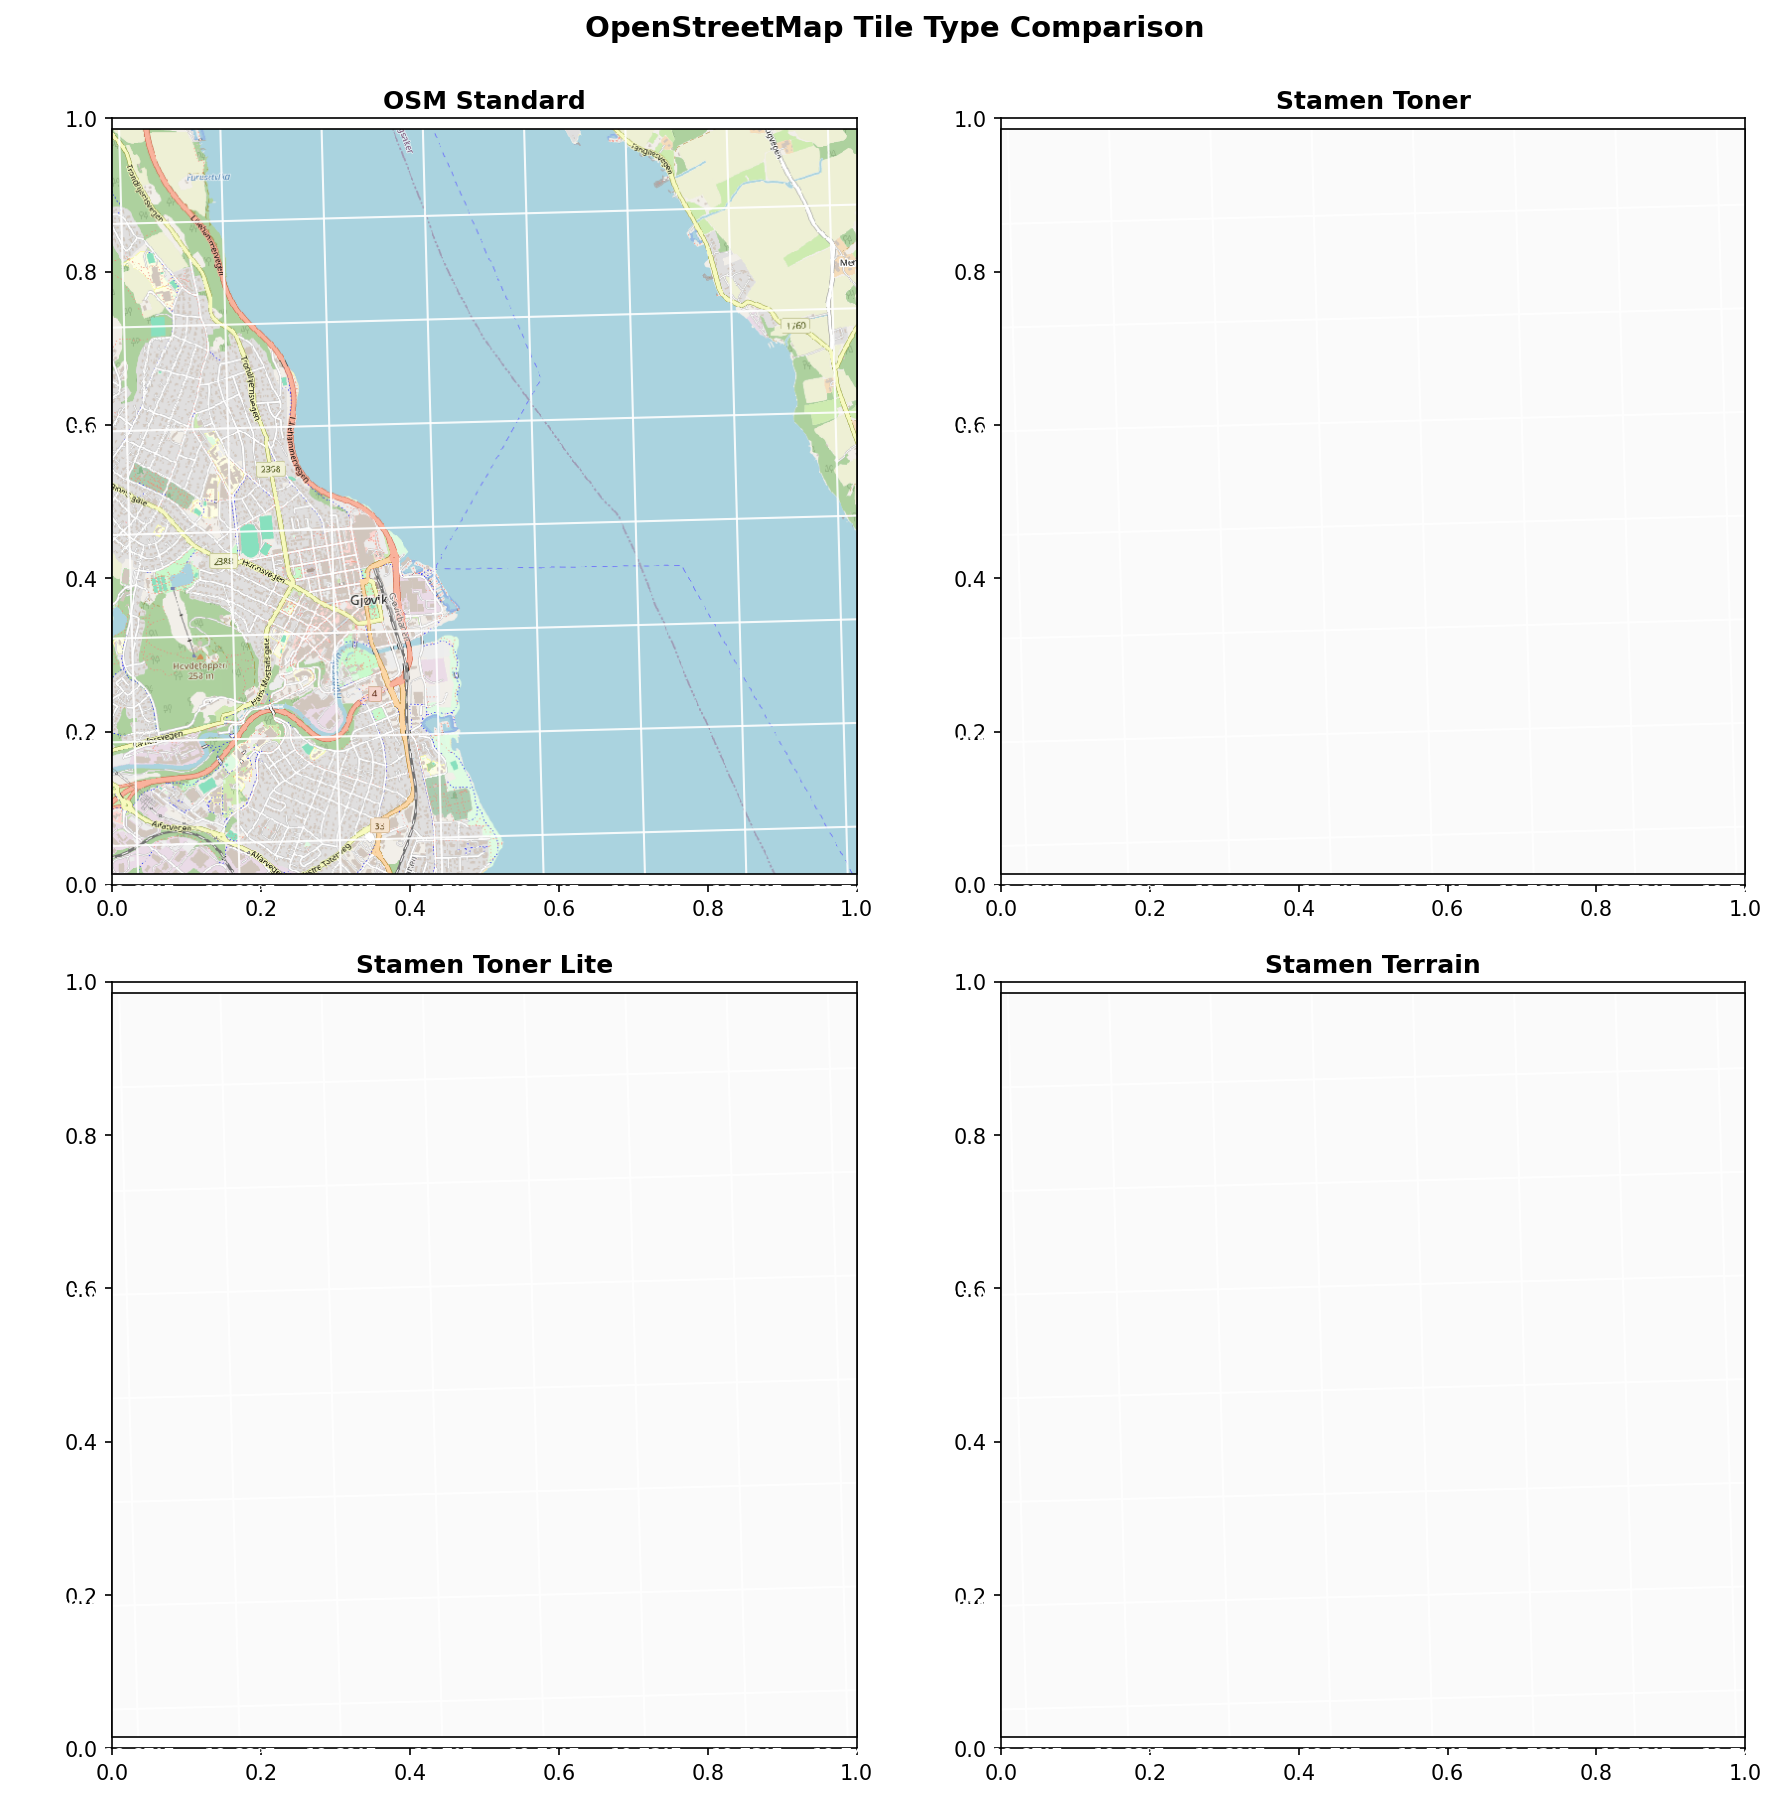


🗺️ AVAILABLE TILE TYPES:
  1. OSM Standard - Full detail with roads, buildings, labels (colorful)
  2. Stamen Toner - High contrast black & white with labels
  3. Stamen Toner Lite - CLEAN B&W, NO labels (best for publications)
  4. Stamen Terrain - Topographic with elevation shading

📌 Recommendation: Use 'Stamen Toner Lite' for clean maps!
   It has the detail without the clutter.


In [ ]:
# COMPARE ALL OPENSTREETMAP TILE TYPES
# Run this to see what's available

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pyproj import Transformer

# Use UTM coordinates from above
LAT_CENTER = config.LAT0
LON_CENTER = config.LON0
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
UTM_EASTING, UTM_NORTHING = transformer.transform(LON_CENTER, LAT_CENTER)
EXTENT_KM = 2  # Smaller for faster loading
EXTENT_METERS = EXTENT_KM * 1000
extent_utm = [
    UTM_EASTING - EXTENT_METERS,
    UTM_EASTING + EXTENT_METERS,
    UTM_NORTHING - EXTENT_METERS,
    UTM_NORTHING + EXTENT_METERS,
]
utm_crs = ccrs.UTM(zone=32, southern_hemisphere=False)

# Available tile types
tile_types = {
    "OSM Standard": cimgt.OSM(),  # Default (what you called "shit")
    "Stamen Toner": cimgt.Stamen("toner"),  # High contrast B&W
    "Stamen Toner Lite": cimgt.Stamen("toner-lite"),  # Clean B&W, no labels
    "Stamen Terrain": cimgt.Stamen("terrain-background"),  # Topographic
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=150)
axes = axes.flatten()

for idx, (name, tile_source) in enumerate(tile_types.items()):
    ax = plt.subplot(2, 2, idx + 1, projection=utm_crs)
    ax.set_extent(extent_utm, crs=utm_crs)

    try:
        ax.add_image(tile_source, 14)  # Lower zoom for speed

        # White gridlines
        gl = ax.gridlines(
            draw_labels=True,
            linewidth=1.0,
            color="white",
            alpha=0.9,
            linestyle="-",
            crs=ccrs.PlateCarree(),
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 8, "color": "white", "weight": "bold"}
        gl.ylabel_style = {"size": 8, "color": "white", "weight": "bold"}
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        ax.set_title(name, fontsize=12, weight="bold", pad=10)
    except Exception as e:
        ax.text(
            0.5,
            0.5,
            f"Failed to load\n{name}\n{str(e)[:50]}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(name, fontsize=12, weight="bold", pad=10)

plt.suptitle("OpenStreetMap Tile Type Comparison", fontsize=14, weight="bold", y=0.995)
plt.tight_layout()
plt.show()

print("\n🗺️ AVAILABLE TILE TYPES:")
print("  1. OSM Standard - Full detail with roads, buildings, labels (colorful)")
print("  2. Stamen Toner - High contrast black & white with labels")
print("  3. Stamen Toner Lite - CLEAN B&W, NO labels (best for publications)")
print("  4. Stamen Terrain - Topographic with elevation shading")
print("\n📌 Recommendation: Use 'Stamen Toner Lite' for clean maps!")
print("   It has the detail without the clutter.")

In [ ]:
stop

NameError: name 'stop' is not defined

In [20]:
# SAVE HIGH-RESOLUTION OSM MAP FOR PUBLICATION

# Settings
OUTPUT_FORMAT = (
    "png"  # 'png' for raster, 'pdf' for vector (but tiles are raster anyway)
)
OUTPUT_DPI = 600  # High resolution for publication
ZOOM_LEVEL = 17  # Very high detail

# Create the map
fig = plt.figure(figsize=(8, 8), dpi=OUTPUT_DPI)
tile_source = cimgt.OSM()
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add high-zoom tiles
ax.add_image(tile_source, ZOOM_LEVEL)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.8, color="red", alpha=0.6, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10, "color": "black", "weight": "bold"}
gl.ylabel_style = {"size": 10, "color": "black", "weight": "bold"}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.08 * (extent[1] - extent[0])
scale_y = extent[2] + 0.08 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=5,
    transform=ccrs.PlateCarree(),
    zorder=10,
)
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
    zorder=11,
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.008,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=10,
    weight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        alpha=0.9,
    ),
)

plt.title(f"Lake Mjøsa Study Site", fontsize=12, pad=15, weight="bold")
plt.tight_layout()

# Save
output_file = f"osm_map_{EXTENT_KM*2:.0f}km_zoom{ZOOM_LEVEL}.{OUTPUT_FORMAT}"
plt.savefig(
    output_file,
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
print(f"✅ Saved: {output_file}")
print(f"   Resolution: {OUTPUT_DPI} DPI")
print(f"   Zoom level: {ZOOM_LEVEL}")
print(f"   File size: ~{os.path.getsize(output_file)/1024/1024:.1f} MB")
print("\n📝 Attribution required:")
print("   'Map data © OpenStreetMap contributors, www.openstreetmap.org'")
print("   License: ODbL (Open Database License)")

plt.show()

C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_239072\2516060535.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Saved: osm_map_5km_zoom17.png
   Resolution: 600 DPI
   Zoom level: 17


NameError: name 'os' is not defined

In [ ]:
# COMPARISON: Different drawn map styles (NOT satellite)
# Shows OSM standard, Stamen Toner Lite, and Stamen Terrain side-by-side

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()}
)

# Style 1: OSM Standard (full detail with labels)
tile_osm = cimgt.OSM()
axes[0].set_extent(extent, crs=ccrs.PlateCarree())
axes[0].add_image(tile_osm, 15)
axes[0].set_title("OSM Standard\n(Full detail with labels)", fontsize=10, weight="bold")

# Style 2: Stamen Toner Lite (clean, no labels)
from cartopy.io.img_tiles import Stamen

tile_toner = Stamen("toner-lite")
axes[1].set_extent(extent, crs=ccrs.PlateCarree())
axes[1].add_image(tile_toner, 15)
axes[1].set_title(
    "Stamen Toner Lite\n(Clean B&W, no labels)", fontsize=10, weight="bold"
)

# Style 3: Stamen Terrain (topographic)
tile_terrain = Stamen("terrain-background")
axes[2].set_extent(extent, crs=ccrs.PlateCarree())
axes[2].add_image(tile_terrain, 15)
axes[2].set_title("Stamen Terrain\n(Topographic shading)", fontsize=10, weight="bold")

# Add gridlines to all
for ax in axes:
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}

plt.suptitle(
    "Comparison: Drawn Map Styles (NOT Satellite Imagery)",
    fontsize=13,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("🗺️ All three styles above are DRAWN/RENDERED maps")
print("   → They show cartographic features (roads, land use, labels)")
print("   → They are NOT satellite/aerial photography")
print("\n📌 Choose based on your needs:")
print("   • OSM Standard: Most detail, includes labels")
print("   • Stamen Toner Lite: Clean publication style, no labels")
print("   • Stamen Terrain: Shows elevation and topography")